# LOGISTIC REGRESSION MODEL FOR DIABETES DIAGNOSE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, QuantileTransformer, FunctionTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc, roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.inspection import permutation_importance
import joblib
import re


pd.set_option('display.max_columns', 23)
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2023.csv')
df.loc[df['KidneyDisease'] == 2, 'KidneyDisease'] = 0
df.loc[df['Asthma'] == 2, 'Asthma'] = 0
df.loc[df['COPD'] == 2, 'COPD'] = 0

## Data Preprocessing

### Handling Missing Data
drop the rows which includes unknown features which are detected during EDA

Since rows with unknown feature are a small proportion of our dataset (we know it thanks to EDA), best way to to handle unknown data is dropping the rows with unknown feature 

In [2]:
df = df[df['KidneyDisease'].isin([0.0,1.0])].reset_index(drop=True)
df = df[df['Asthma'].isin([0.0,1.0])].reset_index(drop=True)
df = df[df['COPD'].isin([0.0,1.0])].reset_index(drop=True)

### Feature Encoding
All ordinal variables are already ordinal encoded in dataset

All nominal features are already encoded (Since all nominal features are based on yes/no answers they are binary labeled as 0/1)  in dataset

Then there is no need to any further feature encoding

### Scaling the Data
Since there are too many possible combinations for column transformation I will try the most logical combinations

The reasoning behind the tranformation/scaling selection is that to see whether the best scaling/tranformation method for a feature which is not distributed normally or not balanced.

From EDA:
- The distribution of the BMI feature appears to be approximately normal
- The distributions of the ordinal features appear to be unbalanced 
- I do not apply any scaling to my nominal variables(since they are binary labeled as 0/1)

I create some scaling options for comparing the effects of scaling decisions on the model's success

In [3]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

scaling_options = [
    #----------------------------------------------------------------------bmi_scaler = StandardScaler()----------------------------------------------------------------------------------------
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",MinMaxScaler(), ordinal_cols),
            ("bmi_scaler", StandardScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",StandardScaler(), ordinal_cols),
            ("bmi_scaler", StandardScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",QuantileTransformer(output_distribution='uniform'), ordinal_cols),
            ("bmi_scaler", StandardScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", StandardScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    #------------------------------------------------ bmi_scaler = RobustScaler() ---------------------------------------------------------------------------
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",MinMaxScaler(), ordinal_cols),
            ("bmi_scaler", RobustScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",StandardScaler(), ordinal_cols),
            ("bmi_scaler", RobustScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",QuantileTransformer(output_distribution='uniform'), ordinal_cols),
            ("bmi_scaler", RobustScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", RobustScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    #---------------------------------------------------- bmi_scaler = MinMaxScaler()------------------------------------------------------------------------
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",MinMaxScaler(), ordinal_cols),
            ("bmi_scaler", MinMaxScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",StandardScaler(), ordinal_cols),
            ("bmi_scaler", MinMaxScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",QuantileTransformer(output_distribution='uniform'), ordinal_cols),
            ("bmi_scaler", MinMaxScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", MinMaxScaler(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    #------------------------------------------------------ bmi_scaler = QuantileTransformer(output_distribution='uniform')------------------------------------------------------------------------
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",MinMaxScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",StandardScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),
    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",QuantileTransformer(output_distribution='uniform'), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    ),

    ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    )
]

## Splitting Data into Train and Test Data

Split the data and guarantee the both train and test sets are balanced

Cross validation will be applied during hyperparameter tunning via GridSearchCV 

In [3]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2060\1687742898.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_train)


([<matplotlib.axis.XTick at 0x2134f7db730>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

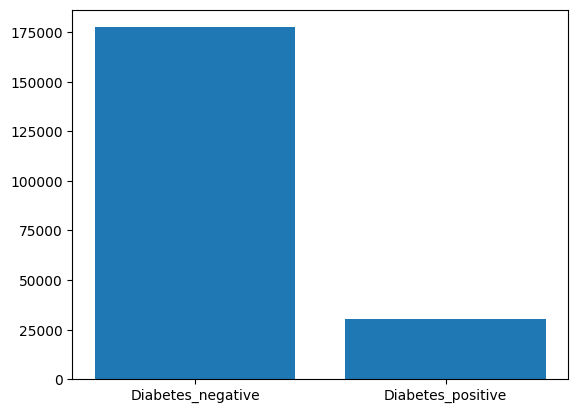

In [5]:
counts = np.bincount(y_train)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2060\52991492.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_test)


([<matplotlib.axis.XTick at 0x2134fa64670>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

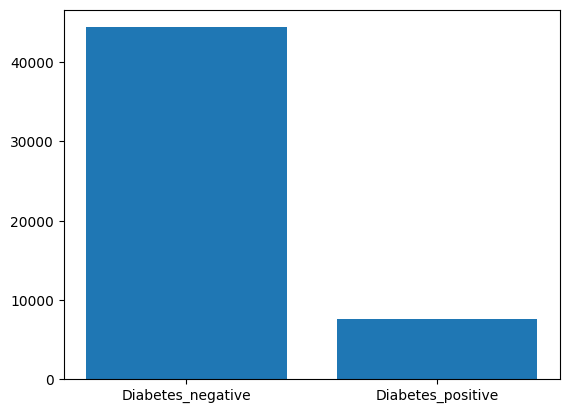

In [6]:
counts = np.bincount(y_test)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])

## Pipeline

- In scaling part the data will be scaled
- In model part the model will be trained

In [7]:
pipe = Pipeline([
    ("scaling",StandardScaler()),
    ("model", LogisticRegression())
])

## Hyperparameter Tuning

- Try every possible combinations with GridSearch and then register all hyperparameter groups' performances metrics for to compare
- For hyperparamatertuning use Cross Validation with 5 fold

In [8]:
param_grids = [
    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["lbfgs"]
    },

    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": [None],
    "model__solver": ["lbfgs"]
    },

    #-------------------------lbfgs-----------------------------------------

    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2","l1"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["liblinear"]
    },
    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2","l1"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["liblinear"]
    },
    #-------------------------liblinear----------------------------------------------
    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["newton-cholesky"]
    },

    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": [None],
    "model__solver": ["newton-cholesky"]
    },
    #-----------------------------newton-cholesky--------------------------------------------------
    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["newton-cg"]
    },

    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": [None],
    "model__solver": ["newton-cg"]
    },
     #--------------------------------- newton-cg ----------------------------------------------
    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": ["l2"],
    "model__C": [0.1 ,0.2 ,0.35 ,0.5 ,1.0, 1.5, 2.0, 2,5],
    "model__solver": ["sag"]
    },

    {
    "scaling": scaling_options,
    "model__max_iter": [30, 50, 100, 150, 200, 300, 400],
    "model__penalty": [None],
    "model__solver": ["sag"]
    },
    #-----------------------------sag--------------------------------------------------
]

In [9]:
grid = GridSearchCV(pipe, param_grids, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)

c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,estimator,Pipeline(step...egression())])
,param_grid,"[{'model__C': [0.1, 0.2, ...], 'model__max_iter': [30, 50, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs'], ...}, {'model__max_iter': [30, 50, ...], 'model__penalty': [None], 'model__solver': ['lbfgs'], 'scaling': [ColumnTransfo...lk', 'Sex'])]), ColumnTransfo...lk', 'Sex'])]), ...]}, ...]"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


In [10]:
grid.best_params_

{'model__max_iter': 30,
 'model__penalty': None,
 'model__solver': 'lbfgs',
 'scaling': ColumnTransformer(remainder='passthrough',
                   transformers=[('ordinal_scaler', RobustScaler(),
                                  ['GenHlth', 'MentHlth', 'PhysHlth', 'AgeGroup',
                                   'Education', 'Income']),
                                 ('bmi_scaler', QuantileTransformer(), ['BMI']),
                                 ('pass_nominal', 'passthrough',
                                  ['KidneyDisease', 'HighBP', 'HighChol',
                                   'CholCheck', 'Asthma', 'COPD', 'Smoker',
                                   'Stroke', 'HeartDiseaseorAttack',
                                   'HvyAlcoholConsump', 'AnyHealthcare',
                                   'NoDocbcCost', 'DiffWalk', 'Sex'])])}

In [11]:
best_model = grid.best_estimator_

## Save the Performance Metrics of Models

In [12]:
grid_results_df = pd.DataFrame(grid.cv_results_)
grid_results_df.to_csv("grid_results_bigger.csv", index=False)

In [13]:
grid_results_df = pd.read_csv("grid_results_bigger.csv")
grid_results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__max_iter,param_model__penalty,param_model__solver,param_scaling,params,split0_test_accuracy,...,mean_test_f1,std_test_f1,rank_test_f1,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
0,1.041195,0.019989,0.092672,0.007278,0.1,30,l2,lbfgs,"ColumnTransformer(remainder='passthrough',\n ...","{'model__C': 0.1, 'model__max_iter': 30, 'mode...",0.858397,...,0.243361,0.003241,5759,0.814596,0.811036,0.805996,0.815904,0.812822,0.812071,0.003453,4030
1,1.013964,0.025794,0.090179,0.002339,0.1,30,l2,lbfgs,"ColumnTransformer(remainder='passthrough',\n ...","{'model__C': 0.1, 'model__max_iter': 30, 'mode...",0.858469,...,0.245242,0.005178,1564,0.814540,0.811101,0.805883,0.815930,0.812913,0.812073,0.003491,3692
2,1.170462,0.043715,0.146307,0.022214,0.1,30,l2,lbfgs,"ColumnTransformer(remainder='passthrough',\n ...","{'model__C': 0.1, 'model__max_iter': 30, 'mode...",0.858181,...,0.235497,0.003928,8370,0.813245,0.810469,0.804854,0.814853,0.812262,0.811137,0.003448,7831
3,1.143507,0.023772,0.085758,0.005806,0.1,30,l2,lbfgs,"ColumnTransformer(remainder='passthrough',\n ...","{'model__C': 0.1, 'model__max_iter': 30, 'mode...",0.858686,...,0.241856,0.003995,6564,0.813852,0.810529,0.804868,0.814852,0.812058,0.811232,0.003511,6906
4,1.083554,0.012482,0.107969,0.012913,0.1,30,l2,lbfgs,"ColumnTransformer(remainder='passthrough',\n ...","{'model__C': 0.1, 'model__max_iter': 30, 'mode...",0.858445,...,0.243050,0.003513,5930,0.814599,0.811178,0.805936,0.815952,0.812914,0.812116,0.003481,1770


In [14]:
joblib.dump(best_model, 'best_logistic_model_bigger.pkl')

['best_logistic_model_bigger.pkl']

In [15]:
# best_model1 is our reference model, I will observe the changes in success metric by using it as reference
best_model1 = joblib.load('best_logistic_model_bigger.pkl')

# Model Evaluation

## Best model's success metrics

### Checking Train Success

In [16]:
y_pred = best_model1.predict(X_train)

In [17]:
accuracy_train = accuracy_score(y_train, y_pred)
accuracy_train

0.8589430835630874

In [18]:
precision_train = precision_score(y_train, y_pred)
precision_train

0.5561129258049463

In [19]:
recall_train = recall_score(y_train, y_pred)
recall_train

0.1574410463042473

In [20]:
f1_score_train = f1_score(y_train, y_pred)
f1_score_train

0.2454054054054054

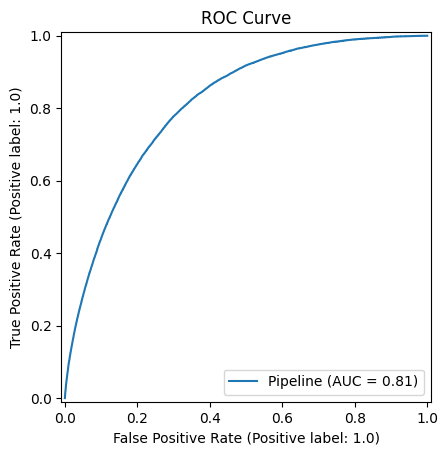

In [21]:
RocCurveDisplay.from_estimator(best_model1, X_train, y_train)
plt.title("ROC Curve")
plt.show()


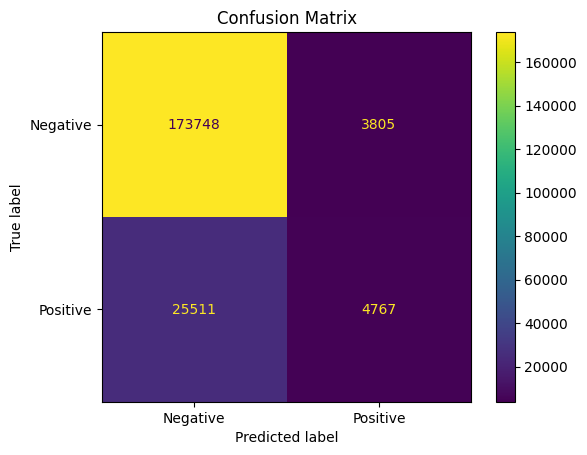

In [22]:
disp = ConfusionMatrixDisplay.from_predictions(y_train, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

### Trying best model with current test split (%80 train/ %20 test)

In [23]:
y_pred = best_model1.predict(X_test)


In [24]:
best_model1.named_steps["model"].n_iter_

array([30], dtype=int32)

In [25]:
weights = best_model1.named_steps["model"].coef_[0]

In [26]:
coef_df = pd.DataFrame({
    "columns": [  'KidneyDisease', 'HighBP', 'HighChol', 'CholCheck',
                'Asthma', 'COPD', 'BMI', 'Smoker', 'Stroke', 
                'HeartDiseaseorAttack','PhysActivity', 'HvyAlcoholConsump', 
                'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 
                'PhysHlth', 'DiffWalk', 'Sex', 'AgeGroup','Education', 'Income'],      
    "weight": weights
})

coef_df.head(22)

,columns,weight
0,KidneyDisease,0.488099
1,HighBP,-0.014145
2,HighChol,-0.024628
3,CholCheck,0.718685
4,Asthma,-0.113126
5,COPD,-0.133528
6,BMI,1.556007
7,Smoker,0.563613
8,Stroke,0.704136
9,HeartDiseaseorAttack,0.531458


In [27]:
accuracy_1 = accuracy_score(y_test, y_pred)
accuracy_1

0.8586743138688941

In [28]:
precision_1 = precision_score(y_test, y_pred)
precision_1

0.5461828463713477

In [29]:
recall_1 = recall_score(y_test, y_pred)
recall_1

0.15373391696511474

In [30]:
f1_score_1 = f1_score(y_test, y_pred)
f1_score_1

0.23993375426974434

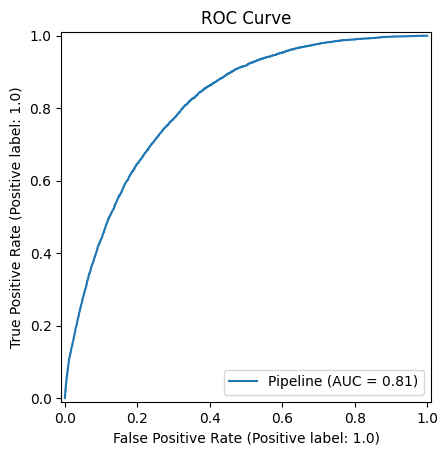

In [31]:
RocCurveDisplay.from_estimator(best_model1, X_test, y_test)
plt.title("ROC Curve")
plt.show()


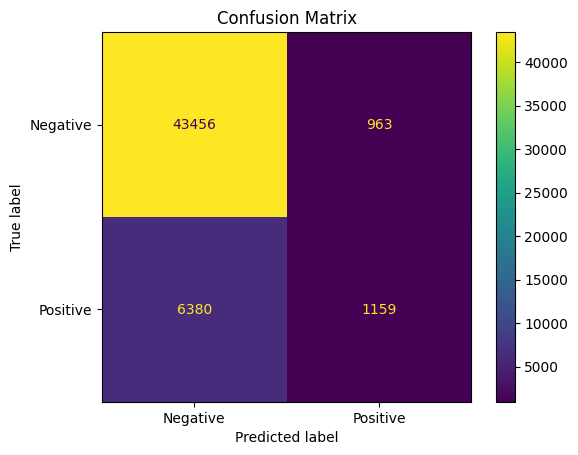

In [32]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

### Checking Overfitting - Underfitting

In [33]:
best_model_split_comparison = pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_train, precision_train, recall_train, f1_score_train]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['best_model(test success)', 'best_model(train_succes)']
)


best_model_split_comparison.head(2)

,Accuracy,precision,recall,f1_score
best_model(test success),0.858674,0.546183,0.153734,0.239934
best_model(train_succes),0.858943,0.556113,0.157441,0.245405


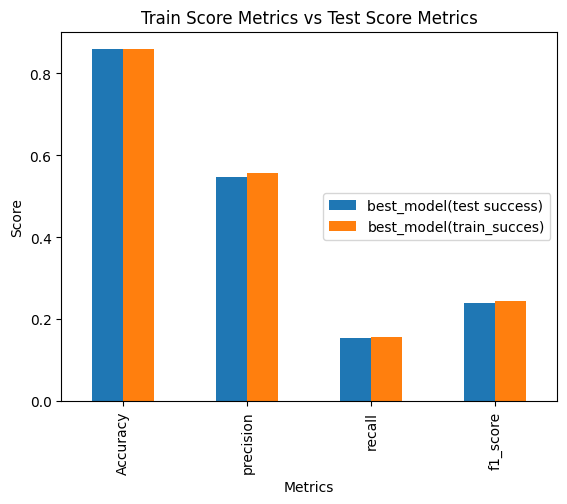

In [34]:
best_model_split_comparison_T = best_model_split_comparison.T
best_model_split_comparison_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Train Score Metrics vs Test Score Metrics")
plt.legend(loc="center right")
plt.show()

### Learning Curve

c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.or

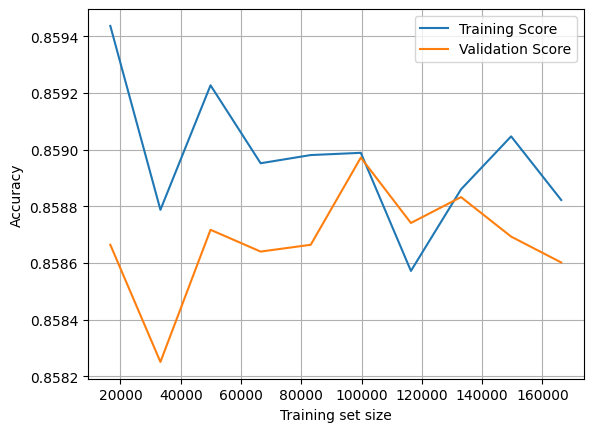

In [35]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model1,
    X_train, y_train,
    cv=5,
    train_sizes = np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.or

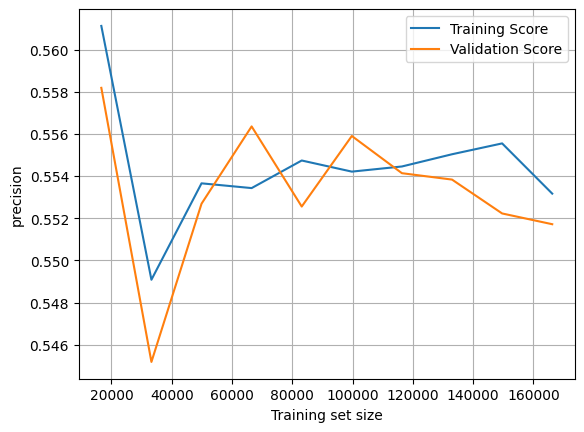

In [36]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model1,
    X_train, y_train,
    cv=5,
    scoring="precision",
    train_sizes = np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training set size")
plt.ylabel("precision")
plt.legend()
plt.grid()
plt.show()

c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.or

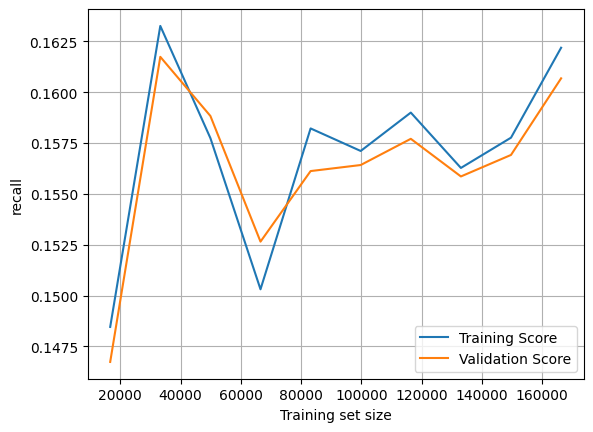

In [37]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model1,
    X_train, y_train,
    cv=5,
    scoring="recall",
    train_sizes = np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training set size")
plt.ylabel("recall")
plt.legend()
plt.grid()
plt.show()

c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.or

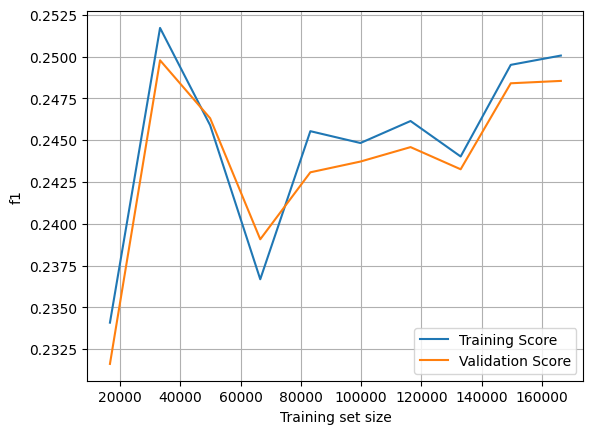

In [38]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model1,
    X_train, y_train,
    cv=5,
    scoring="f1",
    train_sizes = np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training set size")
plt.ylabel("f1")
plt.legend()
plt.grid()
plt.show()

### Trying best model with a larger train split (%90 train/ %10 test)

#### Splitting data (%90 train /%10 test)

In [39]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state= 28)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2060\1687742898.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_train)


([<matplotlib.axis.XTick at 0x21361c39a20>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

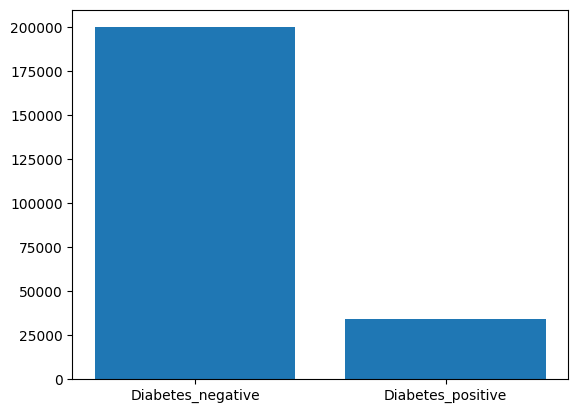

In [40]:
counts = np.bincount(y_train)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2060\52991492.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_test)


([<matplotlib.axis.XTick at 0x21361b72c20>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

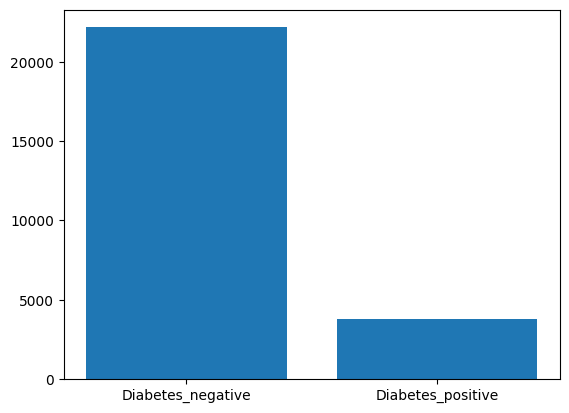

In [41]:
counts = np.bincount(y_test)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])

#### Evaluating Model

In [42]:
best_model1.fit(X_train,y_train)

c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
y_pred = best_model1.predict(X_test)


In [44]:
best_model1.named_steps["model"].n_iter_

array([30], dtype=int32)

In [45]:
accuracy_2 = accuracy_score(y_test, y_pred)
accuracy_2

0.857500288694715

In [46]:
precision_2 = precision_score(y_test, y_pred)
precision_2

0.5414767547857794

In [47]:
recall_2 = recall_score(y_test, y_pred)
recall_2

0.15660427102557342

In [48]:
f1_score_2 = f1_score(y_test, y_pred)
f1_score_2

0.24294478527607363

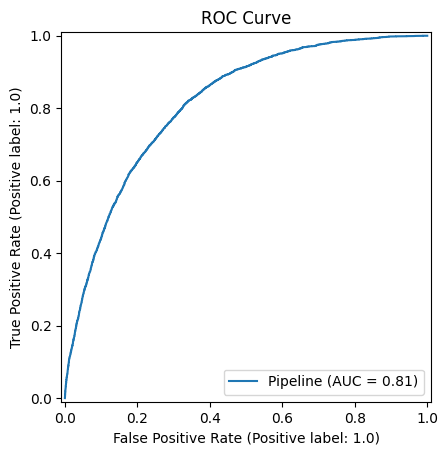

In [49]:
RocCurveDisplay.from_estimator(best_model1, X_test, y_test)
plt.title("ROC Curve")
plt.show()


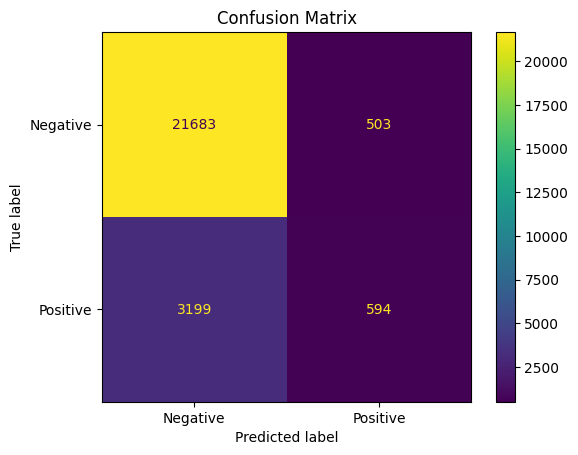

In [50]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

In [51]:
best_model_split_comparison = pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_2, precision_2, recall_2, f1_score_2]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['best_model(%20 test split)', 'best_model(%10 test split)']
)


best_model_split_comparison.head(2)

,Accuracy,precision,recall,f1_score
best_model(%20 test split),0.858674,0.546183,0.153734,0.239934
best_model(%10 test split),0.857500,0.541477,0.156604,0.242945


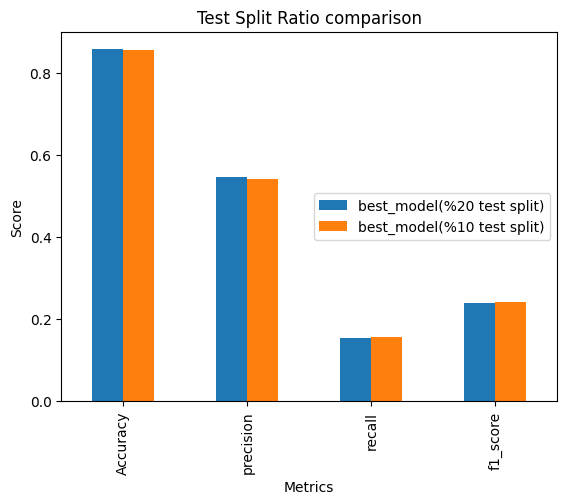

In [52]:

best_model_split_comparison_T = best_model_split_comparison.T
best_model_split_comparison_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Test Split Ratio comparison")
plt.legend(loc="center right")
plt.show()

In [53]:
# best_model1 is our reference model, I will observe the changes in success metric by using it as reference
best_model1 = joblib.load('best_logistic_model_bigger.pkl')

## Comparing Metrics of Different Models
In this section, I will analyze the how the changes in hyperparameters affects on models' success 

- Before I use mean of similar models' metrics to observe how the change in a parameter affects on model's success, I checked the standard deviation of that metric and verify that standard deviation of that metric is small.        

In [54]:
grid_results_df.shape

(8512, 50)

In [55]:
grid_results_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_model__C', 'param_model__max_iter', 'param_model__penalty',
       'param_model__solver', 'param_scaling', 'params',
       'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy',
       'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy',
       'std_test_accuracy', 'rank_test_accuracy', 'split0_test_precision',
       'split1_test_precision', 'split2_test_precision',
       'split3_test_precision', 'split4_test_precision', 'mean_test_precision',
       'std_test_precision', 'rank_test_precision', 'split0_test_recall',
       'split1_test_recall', 'split2_test_recall', 'split3_test_recall',
       'split4_test_recall', 'mean_test_recall', 'std_test_recall',
       'rank_test_recall', 'split0_test_f1', 'split1_test_f1',
       'split2_test_f1', 'split3_test_f1', 'split4_test_f1', 'mean_test_f1',
       'std_test_f1', 'rank_test_f1', 'split0_test_roc_auc',
       '

In [56]:
param_cols = ['param_model__C', 'param_model__max_iter', 'param_model__penalty','param_model__solver', 'param_scaling', 'params']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']

In [57]:
grid_results_df[std_cols].describe()
# standard deviation is small so folds are well partitioned during cross validation

,std_fit_time,std_score_time,std_test_accuracy,std_test_precision,std_test_recall,std_test_f1,std_test_roc_auc
count,8512.000000,8512.000000,8512.000000,8512.000000,8512.000000,8512.000000,8512.000000
mean,0.843957,0.008993,0.000809,0.010560,0.002813,0.003810,0.003404
std,1.637044,0.005307,0.000256,0.002851,0.000580,0.000738,0.000197
min,0.001515,0.000419,0.000193,0.003524,0.001079,0.000874,0.002749
25%,0.047662,0.005871,0.000791,0.010488,0.002451,0.003521,0.003265
50%,0.120796,0.008144,0.000931,0.011786,0.002637,0.003736,0.003509
75%,0.354250,0.011157,0.000955,0.012108,0.003355,0.004046,0.003533
max,13.924160,0.113339,0.001196,0.015550,0.007734,0.010309,0.003900


### Model's Solver's Effects on Model's Metrics
- It is observed that change in model's solver has no significant effect on models success 

In [58]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__solver", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results.head(5)


,param_model__solver,test_accuracy_std,test_f1_std,roc_auc_std
0,lbfgs,0.000162,0.003463,0.000635
1,liblinear,0.000160,0.003356,0.000565
2,newton-cg,0.000159,0.003240,0.000569
3,newton-cholesky,0.000162,0.003270,0.000568
4,sag,0.000164,0.003265,0.000566


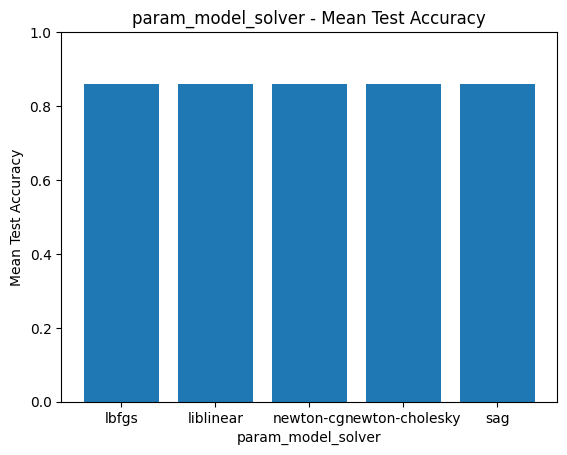

In [59]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__solver")["mean_test_accuracy"].mean().reset_index()

plt.bar(results["param_model__solver"], results["mean_test_accuracy"])
plt.xlabel("param_model_solver")
plt.ylabel("Mean Test Accuracy")
plt.title("param_model_solver - Mean Test Accuracy")
plt.ylim(0, 1)
plt.show()

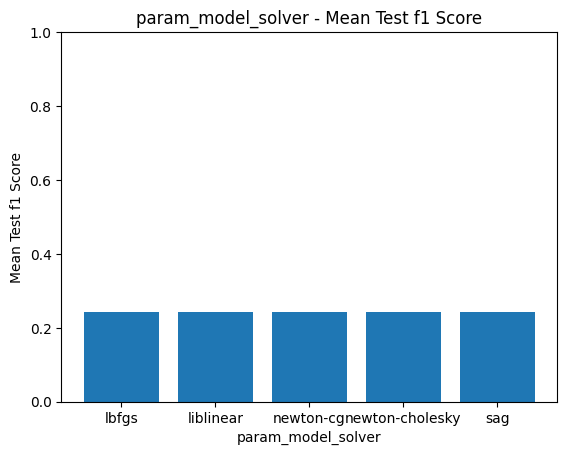

In [60]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__solver")["mean_test_f1"].mean().reset_index()



plt.bar(results["param_model__solver"], results["mean_test_f1"])
plt.xlabel("param_model_solver")
plt.ylabel("Mean Test f1 Score")
plt.title("param_model_solver - Mean Test f1 Score")
plt.ylim(0, 1)
plt.show()

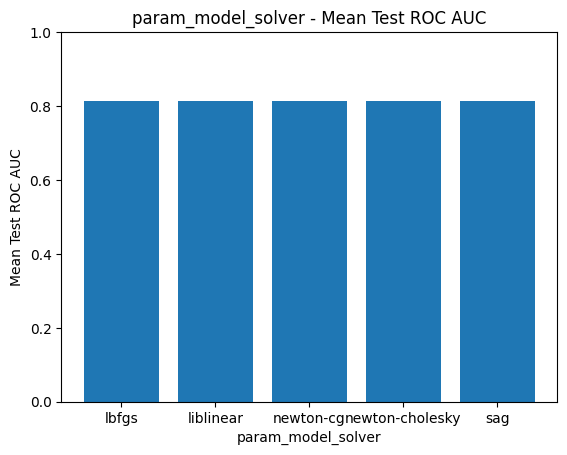

In [61]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__solver")["mean_test_roc_auc"].mean().reset_index()



plt.bar(results["param_model__solver"], results["mean_test_roc_auc"])
plt.xlabel("param_model_solver")
plt.ylabel("Mean Test ROC AUC")
plt.title("param_model_solver - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.show()

### Model's Penalty's Effects on Model's Metrics 

In [62]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__penalty", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results.head(2)


,param_model__penalty,test_accuracy_std,test_f1_std,roc_auc_std
0,l1,0.000156,0.003157,0.000562
1,l2,0.000162,0.003404,0.000580


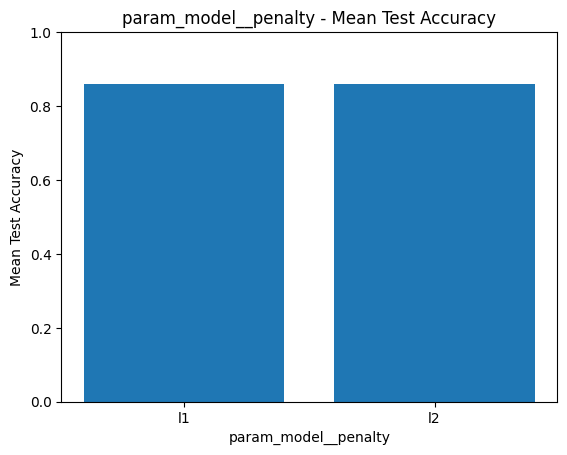

In [63]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__penalty")["mean_test_accuracy"].mean().reset_index()

plt.bar(results["param_model__penalty"], results["mean_test_accuracy"])
plt.xlabel("param_model__penalty")
plt.ylabel("Mean Test Accuracy")
plt.title("param_model__penalty - Mean Test Accuracy")
plt.ylim(0, 1)
plt.show()

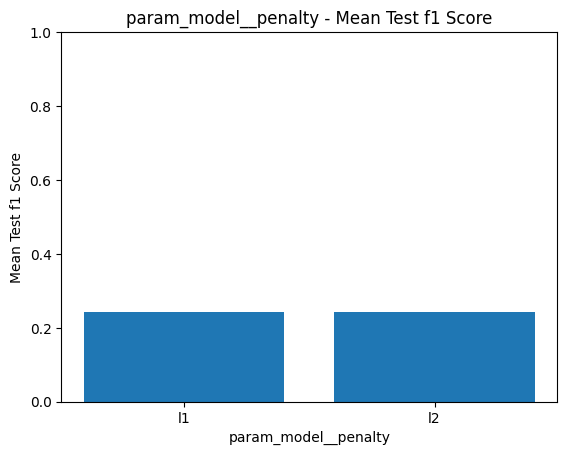

In [64]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__penalty")["mean_test_f1"].mean().reset_index()

plt.bar(results["param_model__penalty"], results["mean_test_f1"])
plt.xlabel("param_model__penalty")
plt.ylabel("Mean Test f1 Score")
plt.title("param_model__penalty - Mean Test f1 Score")
plt.ylim(0, 1)
plt.show()

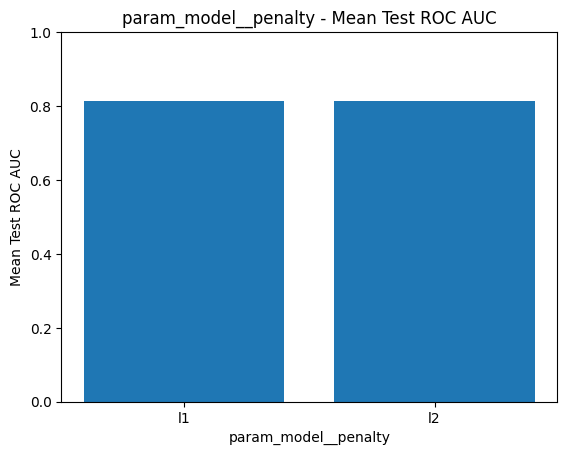

In [65]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__penalty")["mean_test_roc_auc"].mean().reset_index()

plt.bar(results["param_model__penalty"], results["mean_test_roc_auc"])
plt.xlabel("param_model__penalty")
plt.ylabel("Mean Test ROC AUC")
plt.title("param_model__penalty - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.show()

### Max Number of Iteration's Effects on Model's Metrics

In [66]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__max_iter", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results.head(7)


,param_model__max_iter,test_accuracy_std,test_f1_std,roc_auc_std
0,30,0.000162,0.003466,0.000622
1,50,0.000160,0.003317,0.000570
2,100,0.000162,0.003316,0.000568
3,150,0.000160,0.003304,0.000568
4,200,0.000161,0.003310,0.000568
5,300,0.000160,0.003315,0.000569
6,400,0.000161,0.003311,0.000567


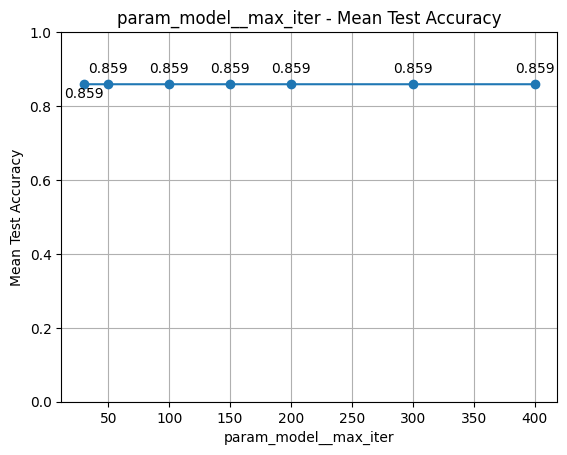

In [67]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__max_iter")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["param_model__max_iter"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("param_model__max_iter")
plt.ylabel("Mean Test Accuracy")
plt.title("param_model__max_iter - Mean Test Accuracy")
plt.ylim(0, 1)
plt.grid(True)

offsets = [-10, 8, 8, 8, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__max_iter"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1



plt.show()

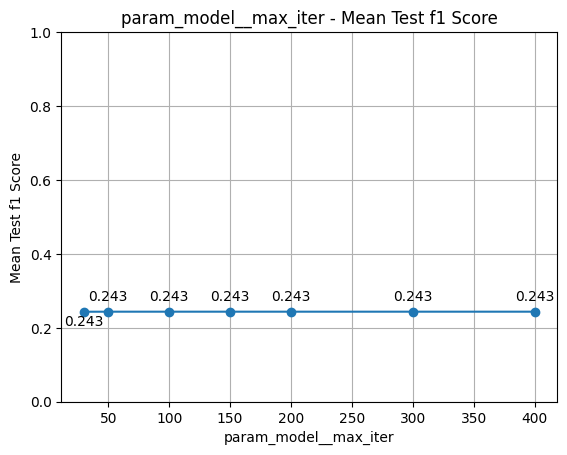

In [68]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__max_iter")["mean_test_f1"].mean().reset_index()



plt.plot(results["param_model__max_iter"], results["mean_test_f1"], marker = "o")
plt.xlabel("param_model__max_iter")
plt.ylabel("Mean Test f1 Score")
plt.title("param_model__max_iter - Mean Test f1 Score")
plt.ylim(0, 1)
plt.grid(True)

offsets = [-10, 8, 8, 8, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__max_iter"], results["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1



plt.show()

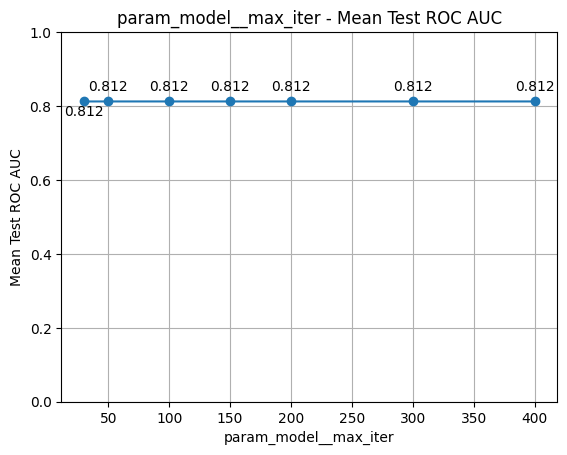

In [69]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__max_iter")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["param_model__max_iter"], results["mean_test_roc_auc"], marker = "o")
plt.xlabel("param_model__max_iter")
plt.ylabel("Mean Test ROC AUC")
plt.title("param_model__max_iter - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)

offsets = [-10, 8, 8, 8, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__max_iter"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1



plt.show()

### Value of C's Effects on Model's Metrics

In [70]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__C", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results.head(8)


,param_model__C,test_accuracy_std,test_f1_std,roc_auc_std
0,0.10,0.000178,0.003980,0.000597
1,0.20,0.000163,0.003467,0.000580
2,0.35,0.000160,0.003249,0.000575
3,0.50,0.000157,0.003177,0.000572
4,1.00,0.000159,0.003099,0.000572
5,1.50,0.000156,0.003058,0.000571
6,2.00,0.000157,0.003061,0.000572
7,5.00,0.000157,0.003053,0.000572


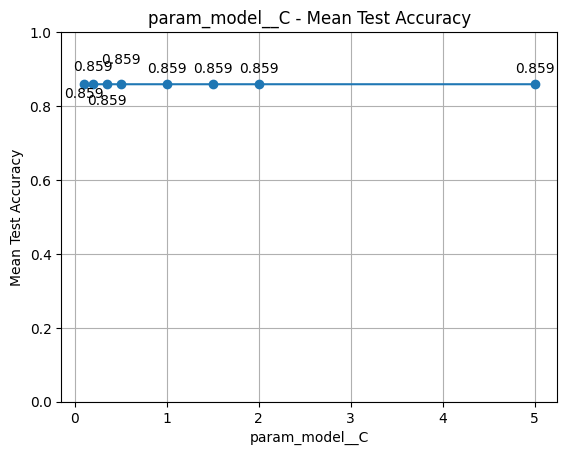

In [71]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__C")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["param_model__C"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("param_model__C")
plt.ylabel("Mean Test Accuracy")
plt.title("param_model__C - Mean Test Accuracy")
plt.ylim(0, 1)
plt.grid(True)

offsets = [-10, 10, -15, 15, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__C"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1



plt.show()

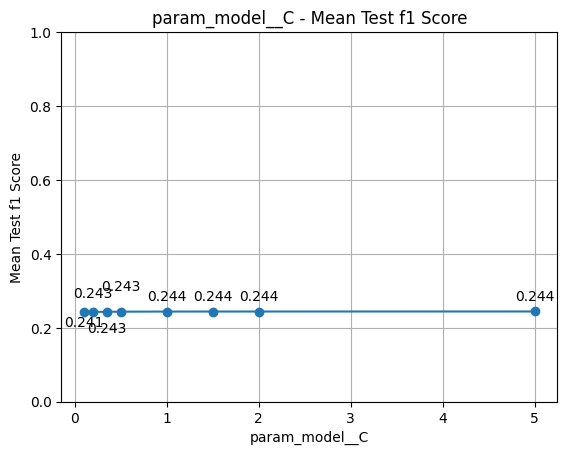

In [72]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__C")["mean_test_f1"].mean().reset_index()



plt.plot(results["param_model__C"], results["mean_test_f1"], marker = "o")
plt.xlabel("param_model__C")
plt.ylabel("Mean Test f1 Score")
plt.title("param_model__C - Mean Test f1 Score")
plt.ylim(0, 1)
plt.grid(True)

offsets = [-10, 10, -15, 15, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__C"], results["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1



plt.show()

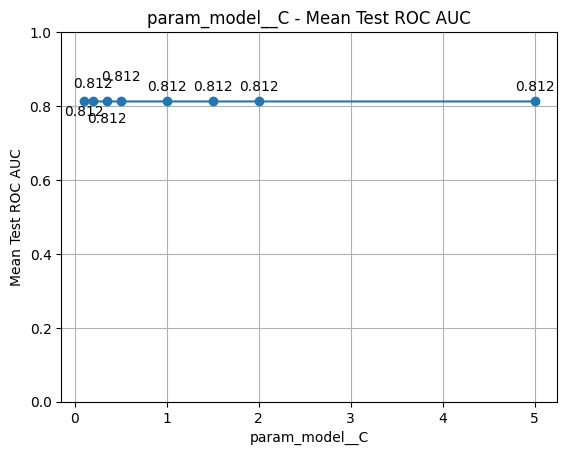

In [73]:
results = grid_results_df[param_cols + mean_cols]

results = results.groupby("param_model__C")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["param_model__C"], results["mean_test_roc_auc"], marker = "o")
plt.xlabel("param_model__C")
plt.ylabel("Mean Test ROC AUC")
plt.title("param_model__C - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)


offsets = [-10, 10, -15, 15, 8, 8, 8, 8]
i = 0
for x, y in zip(results["param_model__C"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1


plt.show()

### Scaling's Effects on Model's Metrics

In [74]:
#function for parsing the scalers in param_scaling column 
def parse_scaler(c):
    scaler_pattern = r"MinMaxScaler|StandardScaler|QuantileTransformer|RobustScaler"
    pattern = fr"ordinal_scaler', ({scaler_pattern}).*bmi_scaler', ({scaler_pattern})"
    x = re.search(pattern, c, flags=re.DOTALL)
    return [x.group(1), x.group(2)]


In [75]:
#add scalers type as seperate columns
results = grid_results_df[param_cols + mean_cols].copy()

results["ordinal_scaler"], results["bmi_scaler"] = zip(*results["param_scaling"].apply(parse_scaler))
results = results.drop(columns=param_cols)

#### Ordinal Scaler's Effects on Success Metrics

In [76]:
results_0 = results.groupby("ordinal_scaler", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results_0.head(4)


,ordinal_scaler,test_accuracy_std,test_f1_std,roc_auc_std
0,MinMaxScaler,0.000091,0.001676,0.000401
1,QuantileTransformer,0.000244,0.002445,0.000421
2,RobustScaler,0.000086,0.001649,0.000459
3,StandardScaler,0.000082,0.001528,0.000403


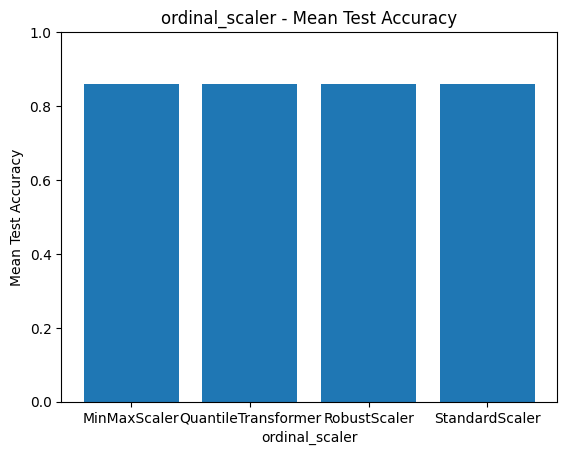

In [77]:
results_0 = results.groupby("ordinal_scaler")["mean_test_accuracy"].mean().reset_index()

plt.bar(results_0["ordinal_scaler"], results_0["mean_test_accuracy"])
plt.xlabel("ordinal_scaler")
plt.ylabel("Mean Test Accuracy")
plt.title("ordinal_scaler - Mean Test Accuracy")
plt.ylim(0, 1)
plt.show()

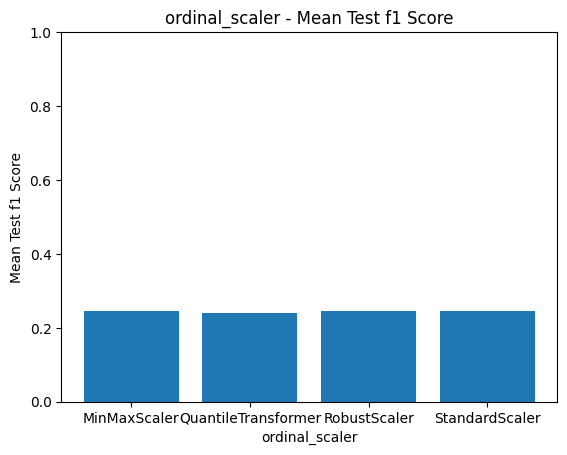

In [78]:
results_0 = results.groupby("ordinal_scaler")["mean_test_f1"].mean().reset_index()

plt.bar(results_0["ordinal_scaler"], results_0["mean_test_f1"])
plt.xlabel("ordinal_scaler")
plt.ylabel("Mean Test f1 Score")
plt.title("ordinal_scaler - Mean Test f1 Score")
plt.ylim(0, 1)
plt.show()

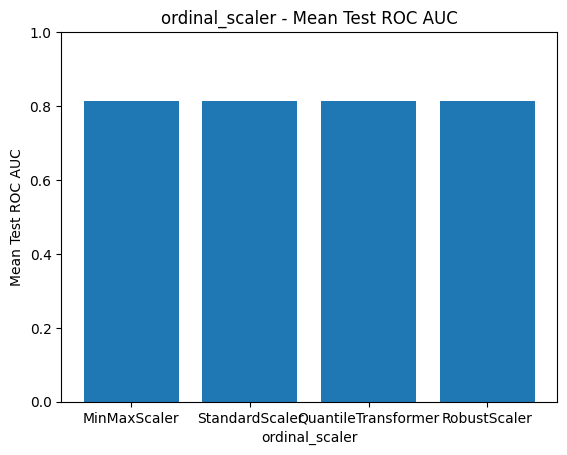

In [79]:
results_0 = results.groupby("ordinal_scaler")["mean_test_roc_auc"].mean().reset_index()

plt.bar(results["ordinal_scaler"], results["mean_test_roc_auc"])
plt.xlabel("ordinal_scaler")
plt.ylabel("Mean Test ROC AUC")
plt.title("ordinal_scaler - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.show()

#### Bmi Scaler's Effects on Success Metrics

In [80]:
results_0 = results.groupby("bmi_scaler", as_index=False).agg(test_accuracy_std=("mean_test_accuracy", "std"), test_f1_std=("mean_test_f1", "std"), roc_auc_std=("mean_test_roc_auc", "std"))
results_0.head(4)

,bmi_scaler,test_accuracy_std,test_f1_std,roc_auc_std
0,MinMaxScaler,0.000119,0.003552,0.000445
1,QuantileTransformer,0.000058,0.002207,0.000386
2,RobustScaler,0.000119,0.003026,0.000400
3,StandardScaler,0.000118,0.003024,0.000402


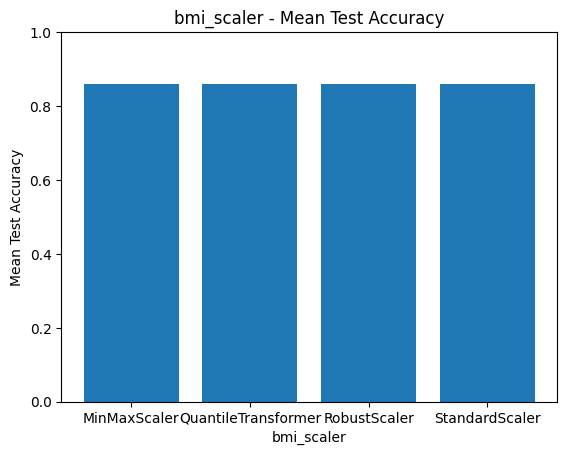

In [81]:
results_0 = results.groupby("bmi_scaler")["mean_test_accuracy"].mean().reset_index()

plt.bar(results_0["bmi_scaler"], results_0["mean_test_accuracy"])
plt.xlabel("bmi_scaler")
plt.ylabel("Mean Test Accuracy")
plt.title("bmi_scaler - Mean Test Accuracy")
plt.ylim(0, 1)
plt.show()

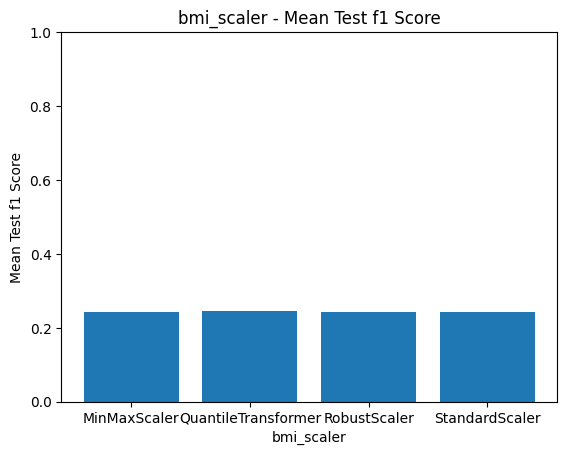

In [82]:
results_0 = results.groupby("bmi_scaler")["mean_test_f1"].mean().reset_index()

plt.bar(results_0["bmi_scaler"], results_0["mean_test_f1"])
plt.xlabel("bmi_scaler")
plt.ylabel("Mean Test f1 Score")
plt.title("bmi_scaler - Mean Test f1 Score")
plt.ylim(0, 1)
plt.show()

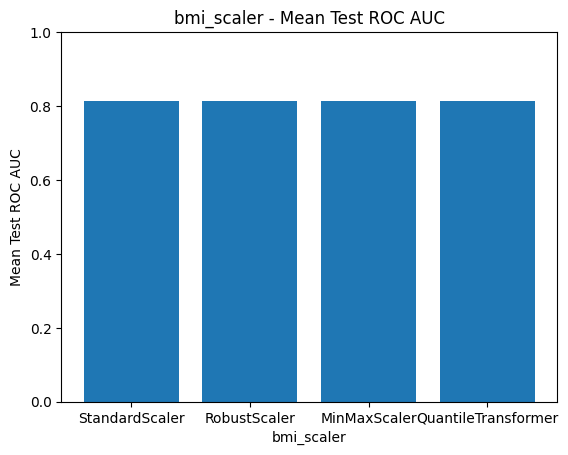

In [83]:
results_0 = results.groupby("bmi_scaler")["mean_test_roc_auc"].mean().reset_index()

plt.bar(results["bmi_scaler"], results["mean_test_roc_auc"])
plt.xlabel("bmi_scaler")
plt.ylabel("Mean Test ROC AUC")
plt.title("bmi_scaler - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.show()

# Improving the Model

## Scaling Improvement

In [84]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

### QuantileTransformer's Parameters

In [85]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

Col_Transformer = ColumnTransformer (
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    )

In [86]:
model_new = Pipeline([
    ("scaling",Col_Transformer),
    ("model", LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])

In [87]:
param_grids = [
    {
    "scaling__bmi_scaler__n_quantiles": [1000, 2000, 5000, 10000],
    "scaling__bmi_scaler__output_distribution": ['uniform', 'normal'],
    "scaling__bmi_scaler__random_state": [0, 28, 42]

    }
]

In [88]:
grid = GridSearchCV(model_new, param_grids, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"[{'scaling__bmi_scaler__n_quantiles': [1000, 2000, ...], 'scaling__bmi_scaler__output_distribution': ['uniform', 'normal'], 'scaling__bmi_scaler__random_state': [0, 28, ...]}]"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


In [89]:
bmi_scaler_result_df = pd.DataFrame(grid.cv_results_)

In [90]:
best_scaler_model = grid.best_estimator_

In [91]:
grid.best_params_

{'scaling__bmi_scaler__n_quantiles': 1000,
 'scaling__bmi_scaler__output_distribution': 'normal',
 'scaling__bmi_scaler__random_state': 42}

In [92]:
best_scaler_model.fit(X_train,y_train)

,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [93]:
y_pred = best_scaler_model.predict(X_test)

In [94]:
accuracy_new = accuracy_score(y_test, y_pred)
accuracy_new

0.8588475306978713

In [95]:
precision_new = precision_score(y_test, y_pred)
precision_new

0.5480093676814989

In [96]:
recall_new = recall_score(y_test, y_pred)
recall_new

0.15519299641862316

In [97]:
f1_score_new = f1_score(y_test, y_pred)
f1_score_new

0.24188546619805665

In [98]:

model_performance_df =  pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_new, precision_new, recall_new, f1_score_new]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['best_model_1', 'best_scaler_model ']
)

In [99]:
model_performance_df.head(2)

,Accuracy,precision,recall,f1_score
best_model_1,0.858674,0.546183,0.153734,0.239934
best_scaler_model,0.858848,0.548009,0.155193,0.241885


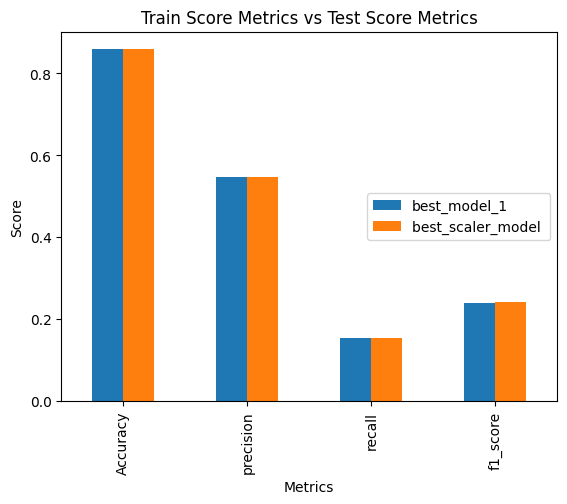

In [100]:

model_performance_df_T = model_performance_df.T
model_performance_df_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Train Score Metrics vs Test Score Metrics")
plt.legend(loc="center right")
plt.show()

In [101]:
param_cols =['param_scaling__bmi_scaler__n_quantiles', 'param_scaling__bmi_scaler__output_distribution', 'param_scaling__bmi_scaler__random_state']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']

In [102]:
bmi_scaler_result_df[std_cols].describe()

,std_fit_time,std_score_time,std_test_accuracy,std_test_precision,std_test_recall,std_test_f1,std_test_roc_auc
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,0.128341,0.007982,0.000523,0.007284,0.003163,0.003782,0.003028
std,0.046242,0.002219,0.000283,0.003095,0.000787,0.000650,0.000113
min,0.046627,0.002093,0.000230,0.004115,0.002279,0.003028,0.002913
25%,0.113551,0.006788,0.000247,0.004266,0.002417,0.003174,0.002915
50%,0.131302,0.007890,0.000520,0.007240,0.003192,0.003804,0.003028
75%,0.142897,0.009253,0.000794,0.010253,0.003930,0.004404,0.003139
max,0.252710,0.011863,0.000825,0.010638,0.003998,0.004526,0.003147


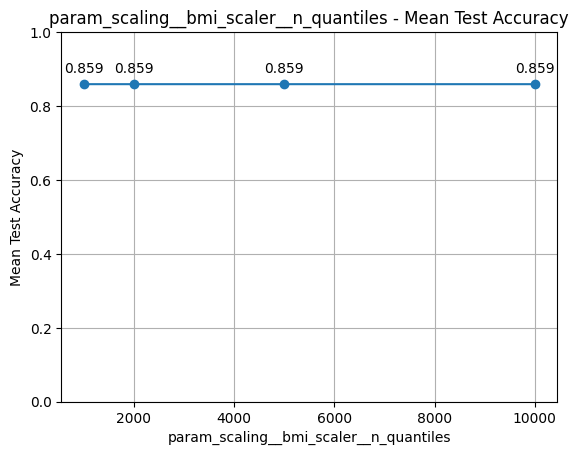

In [103]:
results = bmi_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaling__bmi_scaler__n_quantiles")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("param_scaling__bmi_scaler__n_quantiles")
plt.ylabel("Mean Test Accuracy")
plt.title("param_scaling__bmi_scaler__n_quantiles - Mean Test Accuracy")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

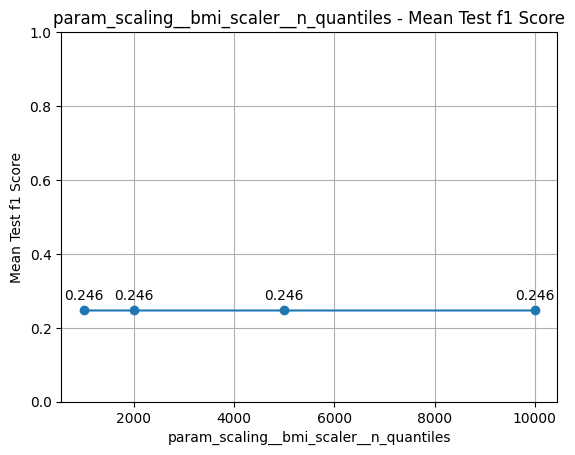

In [104]:
results = bmi_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaling__bmi_scaler__n_quantiles")["mean_test_f1"].mean().reset_index()



plt.plot(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_f1"], marker = "o")
plt.xlabel("param_scaling__bmi_scaler__n_quantiles")
plt.ylabel("Mean Test f1 Score")
plt.title("param_scaling__bmi_scaler__n_quantiles - Mean Test f1 Score")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

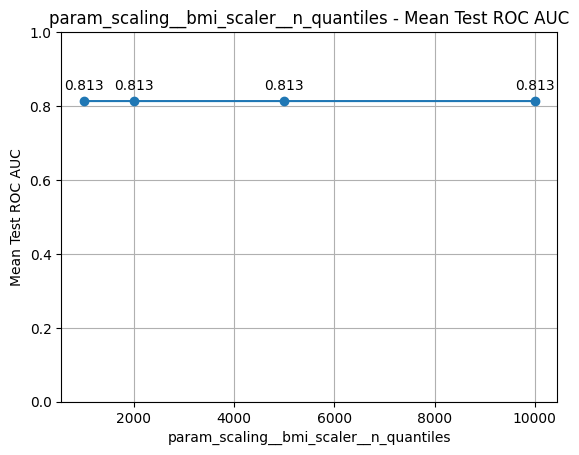

In [105]:
results = bmi_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaling__bmi_scaler__n_quantiles")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_roc_auc"], marker = "o")
plt.xlabel("param_scaling__bmi_scaler__n_quantiles")
plt.ylabel("Mean Test ROC AUC")
plt.title("param_scaling__bmi_scaler__n_quantiles - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["param_scaling__bmi_scaler__n_quantiles"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

### Try Different Scaling Method for Discrete and Ordinal Features 

In [106]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

In [107]:
def power(x, power):
    return x**power

exponential_transformer = FunctionTransformer(power, validate=False)


scaler_pipe = Pipeline ([
    
    ('power', exponential_transformer),
    ('scaler', StandardScaler())            
    
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ('exponential_scale', scaler_pipe, ordinal_cols),
        ('bmi_scale', QuantileTransformer(n_quantiles = 2000, output_distribution = 'uniform', random_state= 42) ,bmi_col),
        ("pass_nominal", "passthrough", nominal_cols)
    ],
    remainder='passthrough'
)

model_new = Pipeline([
    ("scaling",preprocessor),
    ("model", LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])


In [108]:
param_grid = {
    'scaling__exponential_scale__power__kw_args': [
        {'power': 1.1},
        {'power': 1.3},
        {'power': 1.5},
        {'power': 1.7},
        {'power': 2},
        {'power': 3},
    ]
}

In [109]:
grid = GridSearchCV(model_new, param_grid, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)


,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'scaling__exponential_scale__power__kw_args': [{'power': 1.1}, {'power': 1.3}, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('exponential_scale', ...), ('bmi_scale', ...), ...]"


In [110]:
best_scaler_result_df = pd.DataFrame(grid.cv_results_)


In [111]:
best_scaler_model = grid.best_estimator_


In [112]:
grid.best_params_


{'scaling__exponential_scale__power__kw_args': {'power': 1.5}}

In [113]:
best_scaler_model.fit(X_train,y_train)

,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('exponential_scale', ...), ('bmi_scale', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [114]:
y_pred = best_scaler_model.predict(X_test)

In [115]:
accuracy_new = accuracy_score(y_test, y_pred)
accuracy_new


0.8589437622695254

In [116]:
precision_new = precision_score(y_test, y_pred)
precision_new


0.5492957746478874

In [117]:
recall_new = recall_score(y_test, y_pred)
recall_new


0.15519299641862316

In [118]:
f1_score_new = f1_score(y_test, y_pred)
f1_score_new


0.24201054917778467

In [119]:

model_performance_df =  pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_new, precision_new, recall_new, f1_score_new]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['best_model_1', 'best_scaler_model ']
)
model_performance_df.head(2)


,Accuracy,precision,recall,f1_score
best_model_1,0.858674,0.546183,0.153734,0.239934
best_scaler_model,0.858944,0.549296,0.155193,0.242011


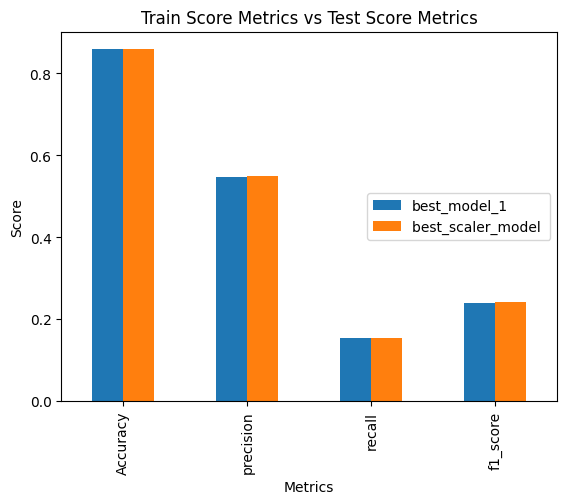

In [120]:

model_performance_df_T = model_performance_df.T
model_performance_df_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Train Score Metrics vs Test Score Metrics")
plt.legend(loc="center right")
plt.show()

In [121]:
best_scaler_result_df["param_scaler_power"] = best_scaler_result_df['param_scaling__exponential_scale__power__kw_args'].apply(lambda d: d["power"])

In [122]:
param_cols =['param_scaler_power']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']

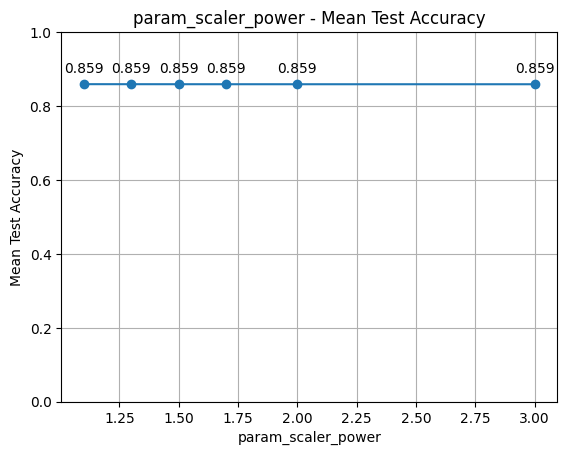

In [123]:
results = best_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaler_power")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["param_scaler_power"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("param_scaler_power")
plt.ylabel("Mean Test Accuracy")
plt.title("param_scaler_power - Mean Test Accuracy")
plt.ylim(0, 1)
plt.grid(True)


for x, y in zip(results["param_scaler_power"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")

plt.show()

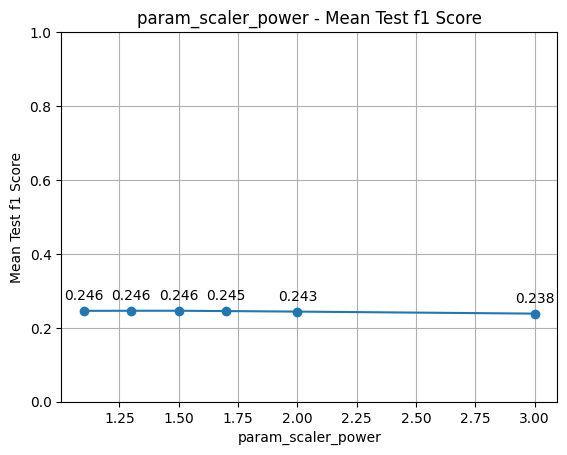

In [124]:
results = best_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaler_power")["mean_test_f1"].mean().reset_index()



plt.plot(results["param_scaler_power"], results["mean_test_f1"], marker = "o")
plt.xlabel("param_scaler_power")
plt.ylabel("Mean Test f1 Score")
plt.title("param_scaler_power - Mean Test f1 Score")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["param_scaler_power"], results["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

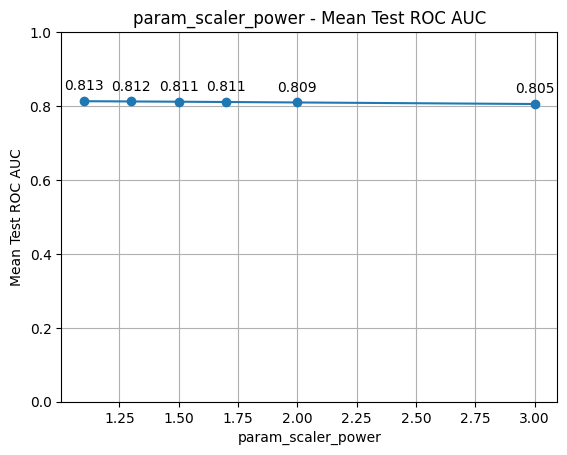

In [125]:
results = best_scaler_result_df[param_cols + mean_cols]

results = results.groupby("param_scaler_power")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["param_scaler_power"], results["mean_test_roc_auc"], marker = "o")
plt.xlabel("param_scaler_power")
plt.ylabel("Mean Test ROC AUC")
plt.title("param_scaler_power - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)

for x, y in zip(results["param_scaler_power"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")


plt.show()

## Tolerance's Effect on Model 

In [126]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

In [127]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

best_Transformer = ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform', random_state=42), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )


In [128]:
model_new = Pipeline([
    ("scaling",best_Transformer),
    ("model", LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])

In [129]:
param_grids = [
    {
    "model__tol": [1e-3, 1e-4, 1e-5, 1e-6]
    }
]

In [130]:
grid = GridSearchCV(model_new, param_grids, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"[{'model__tol': [0.001, 0.0001, ...]}]"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


In [131]:
tol_comparison = pd.DataFrame(grid.cv_results_)

In [132]:
best_tol_model = grid.best_estimator_

In [133]:
grid.best_params_

{'model__tol': 0.0001}

In [134]:
best_tol_model.fit(X_train,y_train)

,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Checking Whether the Change in Tolerance Imporved the Model or not

In [135]:
y_pred = best_tol_model.predict(X_test)

In [136]:
accuracy_new = accuracy_score(y_test, y_pred)
accuracy_new

0.8588475306978713

In [137]:
precision_new = precision_score(y_test, y_pred)
precision_new

0.549636803874092

In [138]:
recall_new = recall_score(y_test, y_pred)
recall_new

0.15055047088473272

In [139]:
f1_score_new = f1_score(y_test, y_pred)
f1_score_new

0.23635985006247398

In [140]:

model_performance_df =  pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_new, precision_new, recall_new, f1_score_new]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['best_model_1', 'best_tol_model ']
)

In [141]:
model_performance_df

,Accuracy,precision,recall,f1_score
best_model_1,0.858674,0.546183,0.153734,0.239934
best_tol_model,0.858848,0.549637,0.150550,0.236360


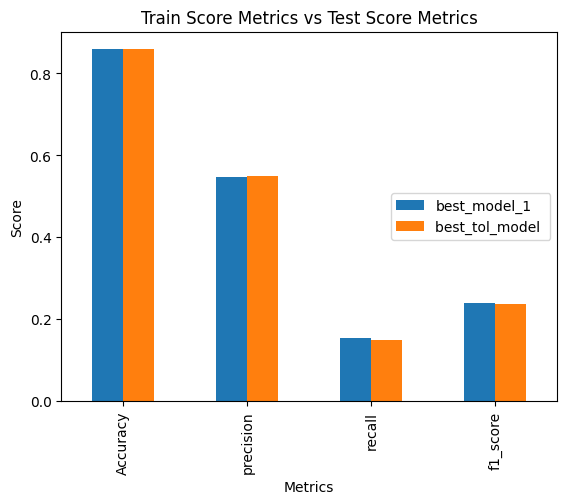

In [142]:

model_performance_df_T = model_performance_df.T
model_performance_df_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Train Score Metrics vs Test Score Metrics")
plt.legend(loc="center right")
plt.show()

### Tolerance's Effect on Model's Success

In [143]:
param_cols =['param_model__tol']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']


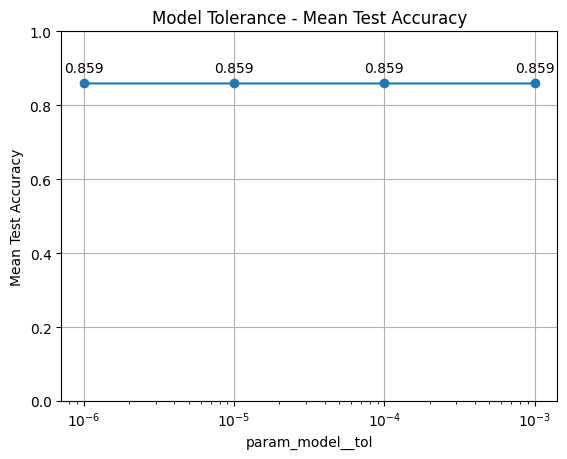

In [144]:
results = tol_comparison[param_cols + mean_cols]

results = results.groupby("param_model__tol")["mean_test_accuracy"].mean().reset_index()



plt.plot(results["param_model__tol"], results["mean_test_accuracy"], marker= "o")
plt.xlabel("param_model__tol")
plt.ylabel("Mean Test Accuracy")
plt.title("Model Tolerance - Mean Test Accuracy")
plt.ylim(0, 1)
plt.xscale("log")
plt.grid(True)

for x, y in zip(results["param_model__tol"], results["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")



plt.show()

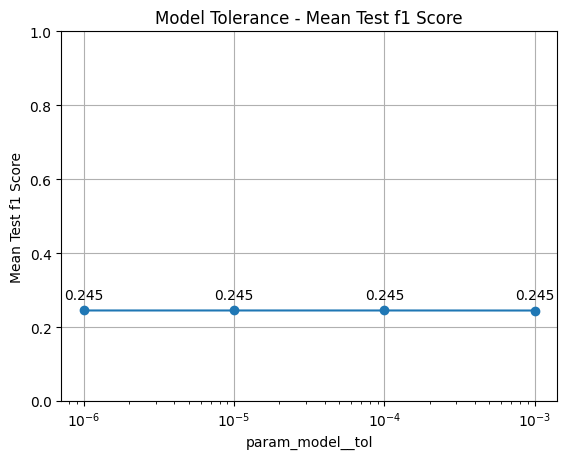

In [145]:
results = tol_comparison[param_cols + mean_cols]

results = results.groupby("param_model__tol")["mean_test_f1"].mean().reset_index()



plt.plot(results["param_model__tol"], results["mean_test_f1"], marker = "o")
plt.xlabel("param_model__tol")
plt.ylabel("Mean Test f1 Score")
plt.title("Model Tolerance - Mean Test f1 Score")
plt.ylim(0, 1)
plt.xscale("log")
plt.grid(True)


for x, y in zip(results["param_model__tol"], results["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")



plt.show()

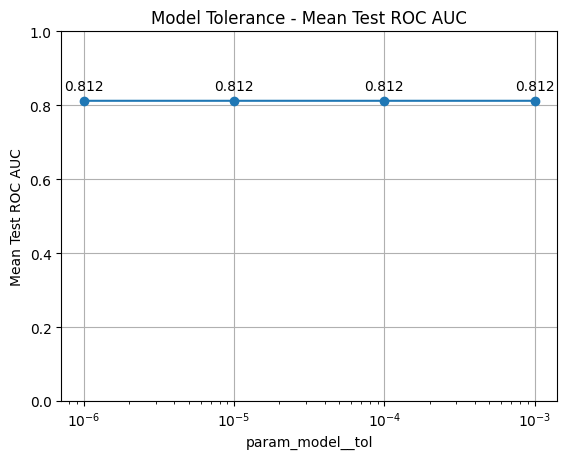

In [146]:
results = tol_comparison[param_cols + mean_cols]

results = results.groupby("param_model__tol")["mean_test_roc_auc"].mean().reset_index()



plt.plot(results["param_model__tol"], results["mean_test_roc_auc"], marker = "o")
plt.xlabel("param_model__tol")
plt.ylabel("Mean Test ROC AUC")
plt.title("Model Tolerance - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.xscale("log")
plt.grid(True)


for x, y in zip(results["param_model__tol"], results["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha="center")



plt.show()

## PCA (Principal Component Analysis)(SORUNLU BAK KONTROL ET)

In [147]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

In [148]:
scale_step = ColumnTransformer(
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform'), bmi_col),
            ("pass_nominal", "passthrough", nominal_cols)
        ],
        remainder="passthrough"
    )

pca_pipe = Pipeline(steps=[
    ("preprocess", scale_step),
    ("pca", PCA(svd_solver="auto", random_state=28)),
    ("model",LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])

In [149]:
param_grid = {
    "pca__n_components": list(range(1,23))
}

In [150]:

grid = GridSearchCV(pca_pipe, param_grid, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv=5, refit="f1")
grid.fit(X_train, y_train)

c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'pca__n_components': [1, 2, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


### Analyzing the Result of PCA

In [151]:
pca_df = pd.DataFrame(grid.cv_results_)
pca_df.to_csv("pca_result_bigger.csv", index=False)

In [152]:
best_model_pca = grid.best_estimator_

In [153]:
### Trying best model with current test split (%80 train/ %20 test)
y_pred = best_model_pca.predict(X_test)

In [154]:
best_model1.named_steps["model"].n_iter_

array([30], dtype=int32)

In [155]:
accuracy_pca = accuracy_score(y_test, y_pred)
accuracy_pca

0.8587320528118865

In [156]:
precision_pca = precision_score(y_test, y_pred)
precision_pca

0.5466479137365213

In [157]:
recall_pca = recall_score(y_test, y_pred)
recall_pca

0.15466242207189282

In [158]:
f1_score_pca = f1_score(y_test, y_pred)
f1_score_pca

0.24110835401157982

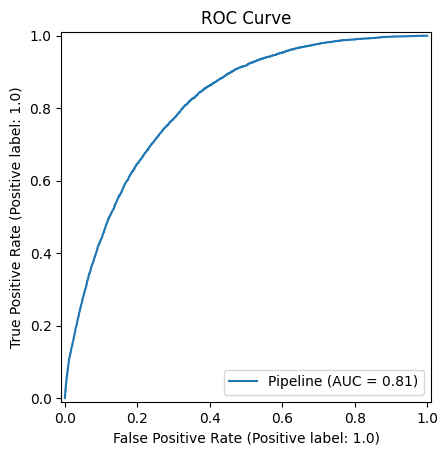

In [159]:
RocCurveDisplay.from_estimator(best_model1, X_test, y_test)
plt.title("ROC Curve")
plt.show()


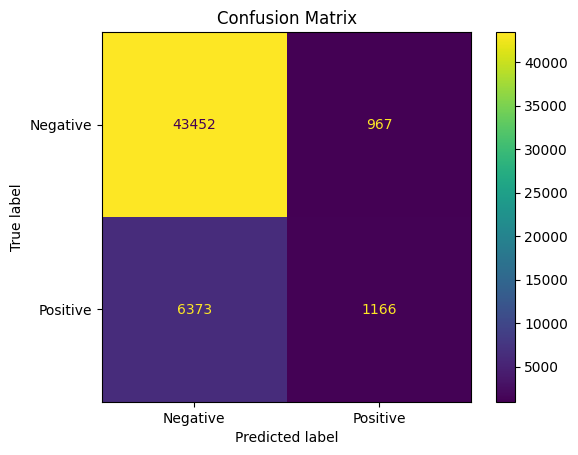

In [160]:

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

In [162]:
pca_df = pd.read_csv("pca_result_bigger.csv")
pca_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_pca__n_components,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,...,mean_test_f1,std_test_f1,rank_test_f1,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
0,0.136572,0.008062,0.048545,0.008997,1,{'pca__n_components': 1},0.854308,0.854328,0.854328,0.854304,0.854304,...,0.000000,0.000000,21,0.639394,0.632541,0.643893,0.636710,0.639012,0.638310,0.003706,22
1,0.159881,0.011456,0.041954,0.005463,2,{'pca__n_components': 2},0.854308,0.854328,0.854328,0.854304,0.854304,...,0.000000,0.000000,21,0.696229,0.687506,0.694097,0.690671,0.691367,0.691974,0.002988,21
2,0.186332,0.007542,0.042735,0.005878,3,{'pca__n_components': 3},0.852311,0.852211,0.852668,0.853053,0.852476,...,0.099912,0.002081,20,0.748987,0.749020,0.747510,0.753146,0.753751,0.750483,0.002489,20
3,0.198467,0.005129,0.047322,0.002203,4,{'pca__n_components': 4},0.853032,0.852187,0.853318,0.853029,0.852596,...,0.112103,0.002678,19,0.758655,0.756448,0.756655,0.760354,0.760232,0.758469,0.001678,19
4,0.223139,0.010231,0.046273,0.007341,5,{'pca__n_components': 5},0.853947,0.853654,0.852091,0.853077,0.853775,...,0.164190,0.005274,17,0.791578,0.788749,0.787123,0.790041,0.791716,0.789841,0.001741,17


In [163]:
param_cols = ['param_pca__n_components']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']

In [164]:
pca_df[std_cols].describe()

,std_fit_time,std_score_time,std_test_accuracy,std_test_precision,std_test_recall,std_test_f1,std_test_roc_auc
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,0.020546,0.004276,0.000414,0.006457,0.002358,0.003114,0.002440
std,0.014060,0.002499,0.000206,0.003127,0.001226,0.001518,0.000469
min,0.002479,0.001194,0.000011,0.000000,0.000000,0.000000,0.001678
25%,0.010031,0.002160,0.000282,0.004679,0.001811,0.002733,0.002239
50%,0.017883,0.003733,0.000380,0.006148,0.002606,0.003435,0.002347
75%,0.031100,0.005829,0.000604,0.008993,0.003216,0.004040,0.002663
max,0.057693,0.010229,0.000744,0.011376,0.003902,0.005371,0.003706


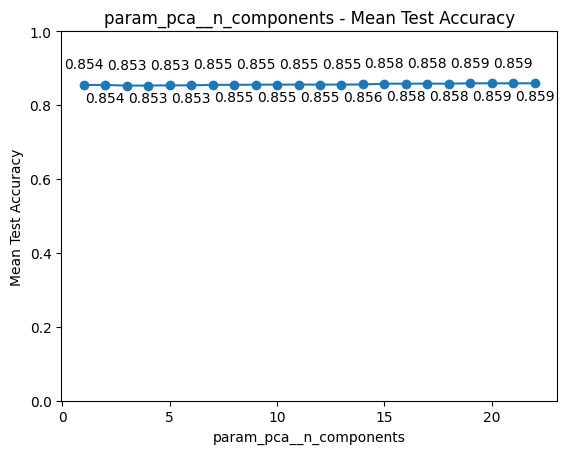

In [165]:
results_pca = pca_df[param_cols + mean_cols]

results_pca = results_pca.groupby("param_pca__n_components")["mean_test_accuracy"].mean().reset_index()

plt.plot(results_pca["param_pca__n_components"], results_pca["mean_test_accuracy"], marker = "o")
plt.xlabel("param_pca__n_components")
plt.ylabel("Mean Test Accuracy")
plt.title("param_pca__n_components - Mean Test Accuracy")
plt.ylim(0, 1)

offsets = [12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12]
i = 0
for x, y in zip(results_pca["param_pca__n_components"], results_pca["mean_test_accuracy"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1


plt.show()

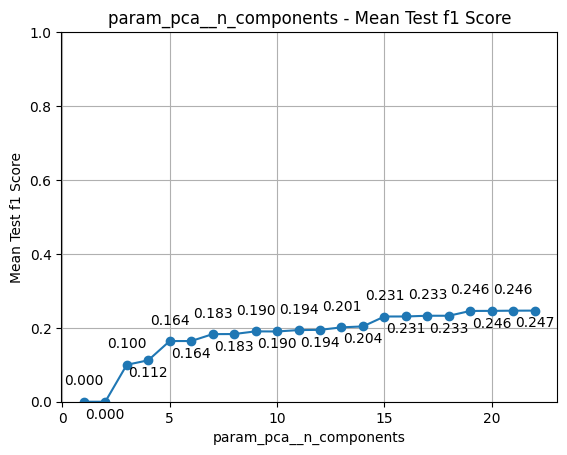

In [166]:
results_pca = pca_df[param_cols + mean_cols]

results_pca = results_pca.groupby("param_pca__n_components")["mean_test_f1"].mean().reset_index()
results_pca.head()


plt.plot(results_pca["param_pca__n_components"], results_pca["mean_test_f1"], marker = "o")
plt.xlabel("param_pca__n_components")
plt.ylabel("Mean Test f1 Score")
plt.title("param_pca__n_components - Mean Test f1 Score")
plt.ylim(0, 1)
plt.grid(True)

offsets = [12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12]
i = 0
for x, y in zip(results_pca["param_pca__n_components"], results_pca["mean_test_f1"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1


plt.show()

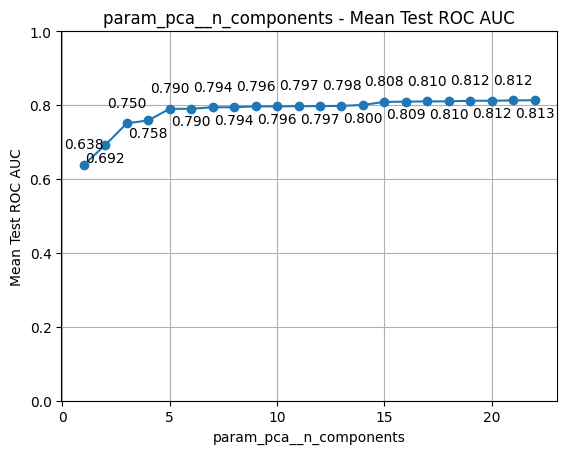

In [167]:
results_pca = pca_df[param_cols + mean_cols]

results_pca = results_pca.groupby("param_pca__n_components")["mean_test_roc_auc"].mean().reset_index()
results_pca.head()


plt.plot(results_pca["param_pca__n_components"], results_pca["mean_test_roc_auc"], marker = "o")
plt.xlabel("param_pca__n_components")
plt.ylabel("Mean Test ROC AUC")
plt.title("param_pca__n_components - Mean Test ROC AUC")
plt.ylim(0, 1)
plt.grid(True)

offsets = [12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12, 12, -12]
i = 0
for x, y in zip(results_pca["param_pca__n_components"], results_pca["mean_test_roc_auc"]):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1


plt.show()

In [168]:
best_pca = grid.best_estimator_.named_steps["pca"]

In [169]:
best_pca.n_components

22

In [170]:
best_pca.explained_variance_

array([6.27803993, 2.97612675, 0.91780495, 0.52393393, 0.38884093,
       0.26746286, 0.21917574, 0.18782722, 0.17391087, 0.16079768,
       0.14049855, 0.12294127, 0.08716196, 0.07545389, 0.06727407,
       0.0634607 , 0.05691462, 0.05539928, 0.0429868 , 0.03647463,
       0.03428282, 0.02757125])

In [171]:
best_pca.mean_

array([-0.42636084,  1.04115724,  1.09689724, -0.00204974,  0.08248048,
        0.06584517,  0.50182172,  0.0492708 ,  0.42836728,  0.41990367,
        0.96535166,  0.14889502,  0.0761436 ,  0.39643268,  0.04188499,
        0.08830733,  0.06285877,  0.96336446,  0.0728284 ,  0.15164244,
        0.48433583,  0.77847386])

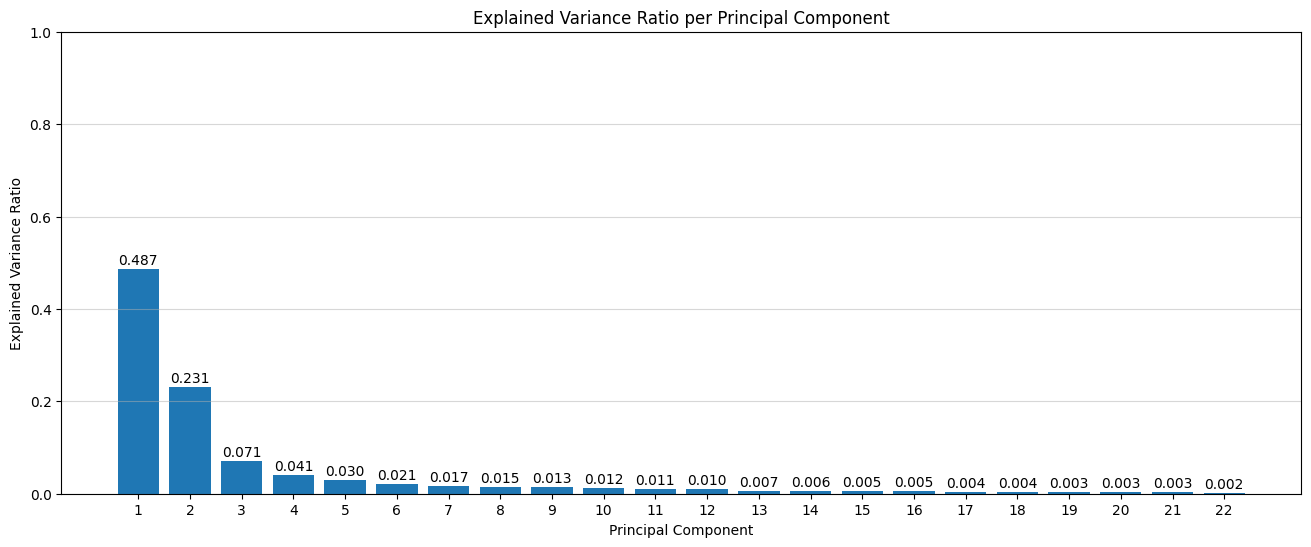

In [172]:
plt.figure(figsize=(16,6))
bars = plt.bar(range(1, 23), best_pca.explained_variance_ratio_)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.3f}", ha='center')

plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, 23))
plt.ylim(0, 1)
plt.grid(axis='y', alpha = 0.5)
plt.show()

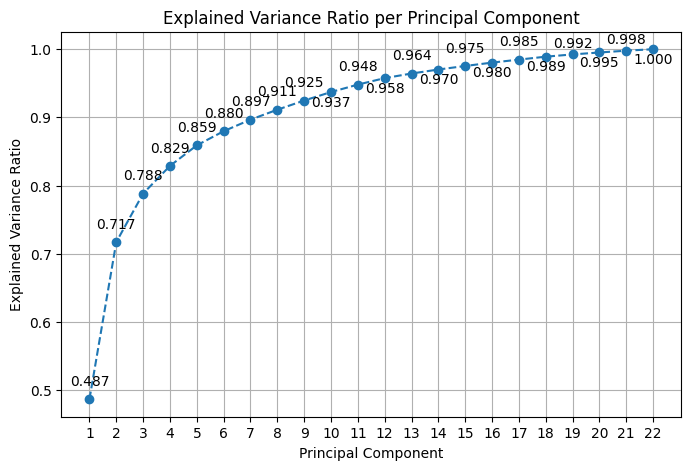

In [173]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 23), best_pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, 23))
plt.grid(True)

offsets = [10, 10, 10, 10, 10, 10, 10, 10, 10, -10, 10, -10, 10, -10, 10, -10, 10, -10, 5, -10, 5, -10]
i = 0
for x, y in zip(range(1, 23), best_pca.explained_variance_ratio_.cumsum()):
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points",
                 xytext=(0, offsets[i]),
                 ha="center")
    i = i + 1

plt.show()

In [174]:
best_pca.noise_variance_

0.0

In [175]:
#DF that shows the how every component constructed from original features

component_df = pd.DataFrame(
    best_pca.components_,
    columns= [  'KidneyDisease', 'HighBP', 'HighChol', 'CholCheck',
                'Asthma', 'COPD', 'BMI', 'Smoker', 'Stroke', 
                'HeartDiseaseorAttack','PhysActivity', 'HvyAlcoholConsump', 
                'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 
                'PhysHlth', 'DiffWalk', 'Sex', 'AgeGroup','Education', 'Income'],
    index=[f"PC{i+1}" for i in range(best_pca.n_components_)]
)

component_df.head(22)

,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
PC1,0.244096,0.576557,0.766134,-0.000402,-0.030880,-0.097058,0.014795,0.012173,0.026420,0.018884,0.000864,0.022856,0.025003,0.028780,0.011163,0.017977,-0.000053,-0.002195,0.021150,0.063329,-0.016240,-0.045727
PC2,-0.097454,0.808871,-0.566801,-0.090501,0.013085,0.023299,-0.003293,-0.011571,-0.038225,-0.025487,-0.005362,0.003745,-0.013110,-0.006416,-0.007541,-0.019182,0.008185,-0.005180,0.016037,-0.042439,-0.019108,0.024687
PC3,0.700318,-0.056647,-0.288150,0.167582,-0.206342,-0.509211,0.060943,0.031239,0.178469,0.111671,0.004540,0.019997,0.056151,0.109336,0.027659,0.061894,-0.009066,-0.012381,0.023269,0.097195,-0.008570,-0.118012
PC4,0.557087,0.002197,-0.072754,0.008418,0.225715,0.764396,0.056965,0.014681,0.098436,0.105077,0.014760,0.010398,-0.005385,-0.023616,0.001806,0.029448,0.008302,0.032525,-0.033119,-0.014459,0.136579,0.044450
PC5,-0.310495,0.085293,0.005717,0.657777,0.079519,0.068173,-0.003258,0.039602,0.436380,0.445295,0.038357,-0.037600,0.043048,0.169435,0.036554,0.099950,0.002911,0.053272,-0.072522,0.075001,0.051199,-0.034998
PC6,-0.081325,0.005509,0.015763,-0.176240,-0.269843,0.017741,0.026811,-0.016160,0.048401,-0.071879,-0.035767,-0.068566,0.025253,0.485065,0.002350,0.043339,0.030997,-0.037102,0.024037,-0.043458,0.794616,0.020463
PC7,0.030165,-0.011089,-0.013837,0.171492,-0.052219,0.171737,-0.095023,-0.008953,-0.285244,-0.226552,-0.004986,0.036497,0.101805,0.759797,0.001017,-0.013519,0.064341,0.015001,-0.011608,0.044580,-0.440693,-0.073841
PC8,-0.038593,-0.038972,0.014560,-0.485173,-0.131549,0.009586,0.071928,-0.021969,-0.059948,0.781893,0.008601,0.126478,0.014323,0.202109,-0.019215,-0.035061,0.031296,-0.029310,0.067183,-0.097550,-0.207430,0.075935
PC9,-0.112892,-0.007404,-0.000130,-0.207794,-0.519236,0.250949,0.191077,0.007060,0.533138,-0.213166,0.006100,0.075937,-0.001421,-0.066972,-0.003124,-0.034139,0.020645,-0.021050,0.010528,0.079900,-0.235035,-0.413682
PC10,-0.007247,-0.024072,0.011889,-0.271695,0.459342,-0.171980,0.069297,0.008260,0.576735,-0.235180,0.009092,0.206486,0.025374,0.249454,-0.000676,-0.013608,0.045542,0.009759,0.046810,-0.071229,-0.111006,0.405587


In [176]:
component_df.to_csv("component_pca_bigger.csv", index=False)

In [177]:
component_df_percent = component_df.abs().div(component_df.abs().sum(axis=1), axis=0) * 100
component_df_percent

,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
PC1,11.949481,28.224731,37.505286,0.019681,1.511718,4.751367,0.724268,0.595921,1.293380,0.924432,0.042292,1.118898,1.224015,1.408876,0.546482,0.880056,0.002574,0.107447,1.035375,3.100212,0.794993,2.238516
PC2,5.268976,43.732735,30.644882,4.893036,0.707466,1.259714,0.178034,0.625620,2.066711,1.377978,0.289917,0.202457,0.708804,0.346877,0.407689,1.037103,0.442510,0.280053,0.867085,2.294538,1.033090,1.334722
PC3,24.498273,1.981606,10.079976,5.862292,7.218168,17.813048,2.131893,1.092792,6.243125,3.906423,0.158801,0.699515,1.964264,3.824760,0.967575,2.165160,0.317141,0.433116,0.813975,3.400048,0.299798,4.128250
PC4,24.643668,0.097188,3.218378,0.372369,9.984884,33.814311,2.519942,0.649418,4.354494,4.648234,0.652922,0.459963,0.238196,1.044672,0.079872,1.302680,0.367243,1.438788,1.465079,0.639614,6.041784,1.966301
PC5,10.908496,2.996554,0.200869,23.109440,2.793698,2.395110,0.114447,1.391338,15.331189,15.644384,1.347587,1.321005,1.512397,5.952713,1.284243,3.511512,0.102255,1.871582,2.547880,2.634973,1.798750,1.229577
PC6,3.474434,0.235365,0.673454,7.529416,11.528372,0.757925,1.145433,0.690382,2.067820,3.070839,1.528052,2.929308,1.078858,20.723236,0.100401,1.851542,1.324275,1.585090,1.026915,1.856624,33.948044,0.874215
PC7,1.145232,0.420986,0.525314,6.510716,1.982504,6.520022,3.607559,0.339912,10.829332,8.601075,0.189298,1.385617,3.865044,28.845765,0.038627,0.513262,2.442703,0.569532,0.440699,1.692492,16.730936,2.803374
PC8,1.502474,1.517225,0.566843,18.888168,5.121309,0.373198,2.800203,0.855263,2.333809,30.439694,0.334827,4.923895,0.557594,7.868276,0.748037,1.364948,1.218360,1.141074,2.615470,3.797698,8.075427,2.956207
PC9,3.748851,0.245869,0.004311,6.900287,17.242471,8.333361,6.345172,0.234440,17.704139,7.078681,0.202549,2.521673,0.047176,2.223963,0.103729,1.133660,0.685569,0.699024,0.349614,2.653268,7.804895,13.737299
PC10,0.239140,0.794368,0.392327,8.965899,15.158205,5.675312,2.286785,0.272569,19.032155,7.760916,0.300034,6.813994,0.837328,8.231935,0.022306,0.449060,1.502866,0.322041,1.544708,2.350559,3.663190,13.384304


## Deleting Outliers
- Delete datapoints who has a BMI more than 60 or less than 11 (BMI = Body Mass Index) 

In [178]:
df = df[(df["BMI"] >= 11) & (df["BMI"] <= 60)]

In [179]:
df.shape

(259328, 23)

In [180]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2060\1687742898.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_train)


([<matplotlib.axis.XTick at 0x21350de0bb0>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

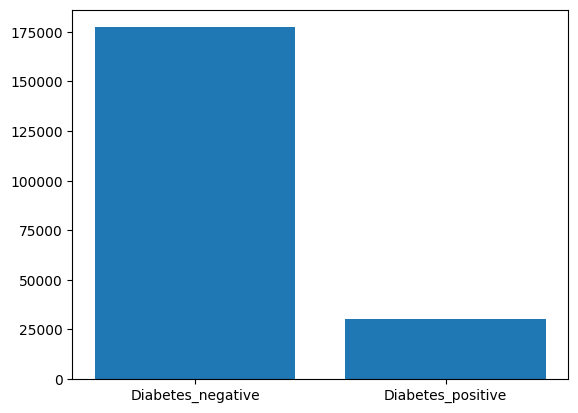

In [181]:
counts = np.bincount(y_train)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2060\52991492.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(y_test)


([<matplotlib.axis.XTick at 0x21352014580>,
 [Text(0, 0, 'Diabetes_negative'), Text(1, 0, 'Diabetes_positive')])

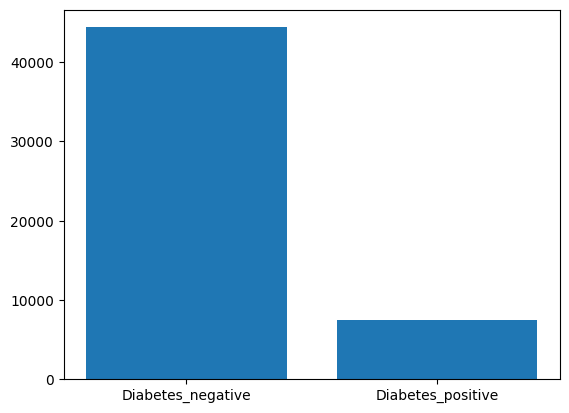

In [182]:
counts = np.bincount(y_test)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, ["Diabetes_negative", "Diabetes_positive"])

In [183]:
best_model1.fit(X_train,y_train)

c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [184]:
y_pred = best_model1.predict(X_test)

In [185]:
accuracy_del = accuracy_score(y_test, y_pred)
precision_del = precision_score(y_test, y_pred)
recall_del = recall_score(y_test, y_pred)
f1_score_del = f1_score(y_test, y_pred)

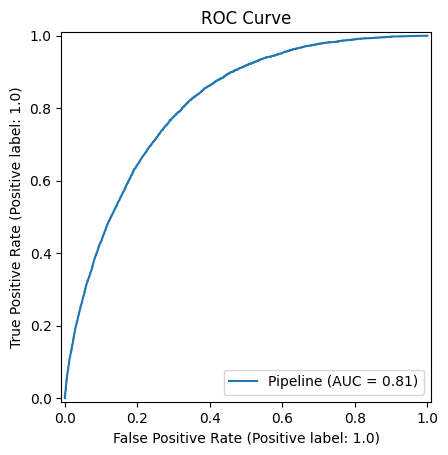

In [186]:
RocCurveDisplay.from_estimator(best_model1, X_test, y_test)
plt.title("ROC Curve")
plt.show()

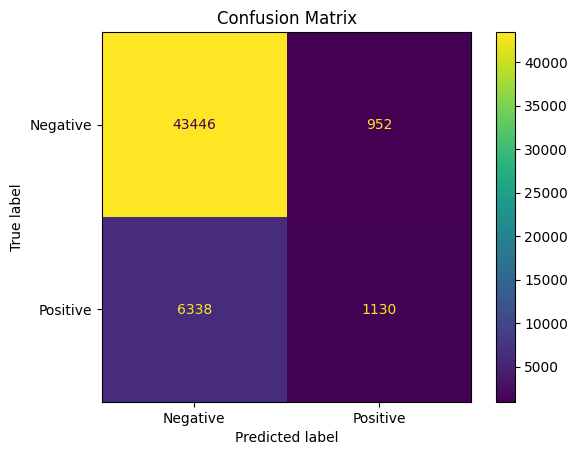

In [187]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

In [188]:
best_model_split_comparison = pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_del, precision_del, recall_del, f1_score_del]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['with_outliers', 'without_outliers']
)


best_model_split_comparison.head(2)

,Accuracy,precision,recall,f1_score
with_outliers,0.858674,0.546183,0.153734,0.239934
without_outliers,0.859445,0.542747,0.151312,0.236649


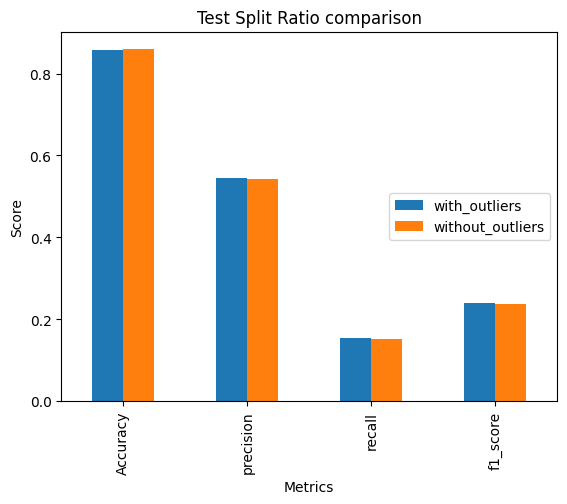

In [189]:
best_model_split_comparison_T = best_model_split_comparison.T
best_model_split_comparison_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Test Split Ratio comparison")
plt.legend(loc="center right")
plt.show()

In [190]:
# Bringing dataframe to it's initial version since removing outliers cause decrease in success metrics
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2023.csv')
df.loc[df['KidneyDisease'] == 2, 'KidneyDisease'] = 0
df.loc[df['Asthma'] == 2, 'Asthma'] = 0
df.loc[df['COPD'] == 2, 'COPD'] = 0
df = df[df['KidneyDisease'].isin([0.0,1.0])].reset_index(drop=True)
df = df[df['Asthma'].isin([0.0,1.0])].reset_index(drop=True)
df = df[df['COPD'].isin([0.0,1.0])].reset_index(drop=True)

In [191]:
# best_model1 is our reference model, I will observe the changes in success metric by using it as reference
best_model1 = joblib.load('best_logistic_model_bigger.pkl')

## Trying Feature Removal

### Measuring The Importance of the Features

In [192]:
y = df["Diabetes_binary"] #label
X = df.drop("Diabetes_binary", axis=1) # feature

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 28)

In [193]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

In [194]:
best_model1.fit(X_train, y_train)
r = permutation_importance(best_model1, X_test, y_test, n_repeats=10)

imp = pd.DataFrame({'feature': best_model1.feature_names_in_, 'importance': r.importances_mean}).sort_values("importance", ascending=False)

c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


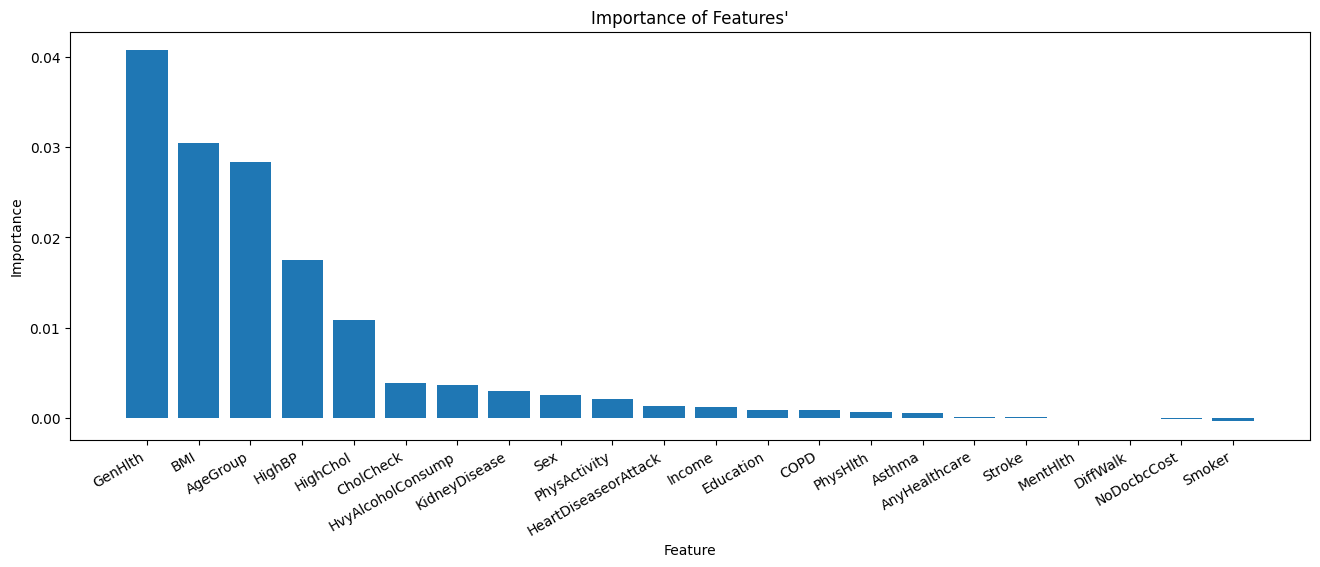

In [195]:
plt.figure(figsize=(16, 6))
plt.bar(imp["feature"], imp["importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Importance of Features'")

plt.gcf().autofmt_xdate()
plt.show()

In [196]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

In [197]:
nominal_cols.remove('AnyHealthcare')
remove_1_feature = ColumnTransformer( #without less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform', random_state=42), bmi_col),
            ("pass_nominal1", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

nominal_cols.remove('NoDocbcCost')
remove_2_feature = ColumnTransformer( #without 2 less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform', random_state=42), bmi_col),
            ("pass_nominal2", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

ordinal_cols.remove('MentHlth')
remove_3_feature = ColumnTransformer( #without 3 less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform', random_state=42), bmi_col),
            ("pass_nominal3", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

nominal_cols.remove('Stroke')
remove_4_feature = ColumnTransformer( #without 4 less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform', random_state=42), bmi_col),
            ("pass_nominal4", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

nominal_cols.remove('Smoker')
remove_5_feature = ColumnTransformer( #without 5 less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform', random_state=42), bmi_col),
            ("pass_nominal5", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

nominal_cols.remove('Asthma')
remove_6_feature = ColumnTransformer( #without 6 less important feature
        transformers= [
            ("ordinal_scaler",RobustScaler(), ordinal_cols),
            ("bmi_scaler", QuantileTransformer(output_distribution='uniform', random_state=42), bmi_col),
            ("pass_nominal6", "passthrough", nominal_cols)
        ],
        remainder="drop"
    )

feature_removals = [remove_1_feature, remove_2_feature, remove_3_feature, remove_4_feature, remove_5_feature, remove_6_feature]

In [198]:
pipe_feature_removal = Pipeline([
    ("scaling",StandardScaler()),
    ("model", LogisticRegression(C=0.1, max_iter=400, penalty="l2", solver="liblinear"))
])

In [199]:
param_grids = {
    'scaling': feature_removals
}

grid = GridSearchCV(pipe_feature_removal, param_grids, scoring = ['accuracy','precision', 'recall' , 'f1', 'roc_auc'], cv = 5, refit= 'f1', n_jobs=-1)
grid.fit(X_train,y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'scaling': [ColumnTransfo...lk', 'Sex'])]), ColumnTransfo...lk', 'Sex'])]), ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"


In [200]:
best_removal_model = grid.best_estimator_

In [201]:
grid.best_params_

{'scaling': ColumnTransformer(transformers=[('ordinal_scaler', RobustScaler(),
                                  ['GenHlth', 'PhysHlth', 'AgeGroup',
                                   'Education', 'Income']),
                                 ('bmi_scaler',
                                  QuantileTransformer(random_state=42),
                                  ['BMI']),
                                 ('pass_nominal1', 'passthrough',
                                  ['KidneyDisease', 'HighBP', 'HighChol',
                                   'CholCheck', 'COPD', 'HeartDiseaseorAttack',
                                   'HvyAlcoholConsump', 'DiffWalk', 'Sex'])])}

In [202]:
removal_results_df = pd.DataFrame(grid.cv_results_)

### Observing Effects of Feature Removal

In [203]:
def how_many_removal(s):
    col_trans_str = str(s)
    pattern = r"pass_nominal(\d)"
    ans = re.search(pattern, col_trans_str)
    if ans:
        return (ans.group(1))

In [204]:
param_cols =['number_of_removed_features']
mean_cols = ['mean_fit_time', 'mean_score_time', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc']
std_cols = ['std_fit_time', 'std_score_time', 'std_test_accuracy', 'std_test_precision', 'std_test_recall', 'std_test_f1', 'std_test_roc_auc']
rank_cols = ['rank_test_accuracy', 'rank_test_precision', 'rank_test_recall', 'rank_test_f1', 'rank_test_roc_auc']


In [205]:
removal_results_df["number_of_removed_features"] = removal_results_df["param_scaling"].apply(how_many_removal)

In [206]:
results_df = removal_results_df[param_cols + mean_cols]
results_df

,number_of_removed_features,mean_fit_time,mean_score_time,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc
0,1,0.351478,0.050481,0.742465,0.741217,0.788944,0.764326,0.815007
1,2,0.387531,0.052721,0.742465,0.741217,0.788944,0.764326,0.815007
2,3,0.357340,0.050257,0.742465,0.741217,0.788944,0.764326,0.815007
3,4,0.316016,0.039249,0.742465,0.741217,0.788944,0.764326,0.815007
4,5,0.294643,0.039016,0.742465,0.741217,0.788944,0.764326,0.815007
5,6,0.190807,0.021629,0.742465,0.741217,0.788944,0.764326,0.815007


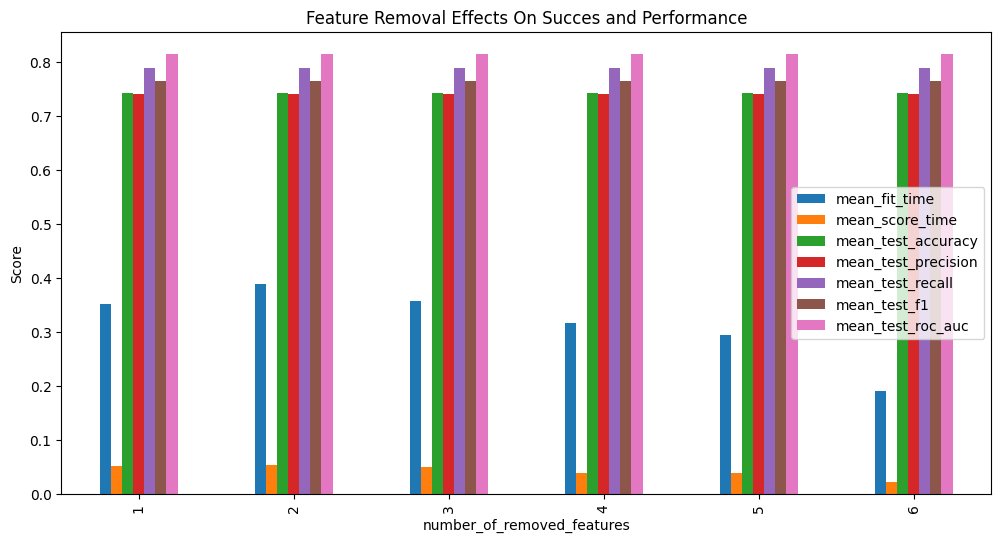

In [207]:
results_df.plot(x="number_of_removed_features" ,kind="bar", figsize=(12,6))
plt.xlabel("number_of_removed_features")
plt.ylabel("Score")
plt.title("Feature Removal Effects On Succes and Performance")
plt.legend(loc="center right")

plt.show()

### Compare Feature Removal Model's Success with First Model's Success

In [208]:
best_removal_model.fit(X_train,y_train)

y_pred = best_removal_model.predict(X_test)

accuracy_new = accuracy_score(y_test, y_pred)
precision_new = precision_score(y_test, y_pred)
recall_new = recall_score(y_test, y_pred)
f1_score_new = f1_score(y_test, y_pred)

model_performance_df =  pd.DataFrame(
    data=[[accuracy_1, precision_1, recall_1, f1_score_1], [accuracy_new, precision_new, recall_new, f1_score_new]],
    columns=['Accuracy', 'precision', 'recall','f1_score'],
    index=['best_model_1', 'model_without_AnyHealthCare ']
)

In [209]:
model_performance_df

,Accuracy,precision,recall,f1_score
best_model_1,0.858674,0.546183,0.153734,0.239934
model_without_AnyHealthCare,0.744696,0.750806,0.788356,0.769123


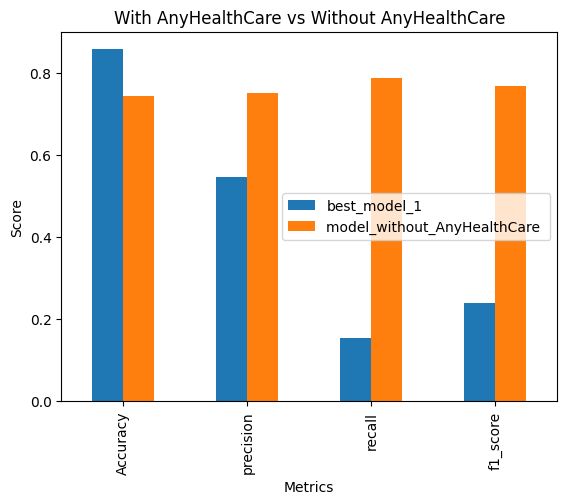

In [210]:
model_performance_df_T = model_performance_df.T
model_performance_df_T.plot(kind="bar")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("With AnyHealthCare vs Without AnyHealthCare")
plt.legend(loc="center right")
plt.show()

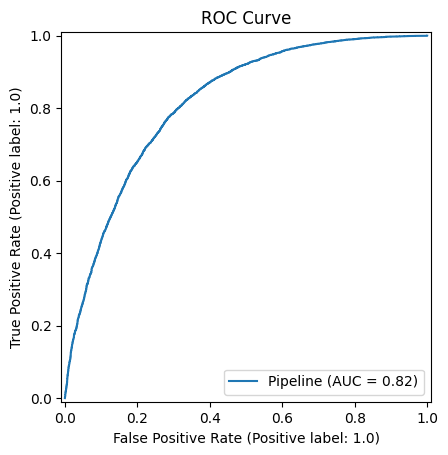

In [211]:

RocCurveDisplay.from_estimator(best_model1, X_test, y_test)
plt.title("ROC Curve")
plt.show()

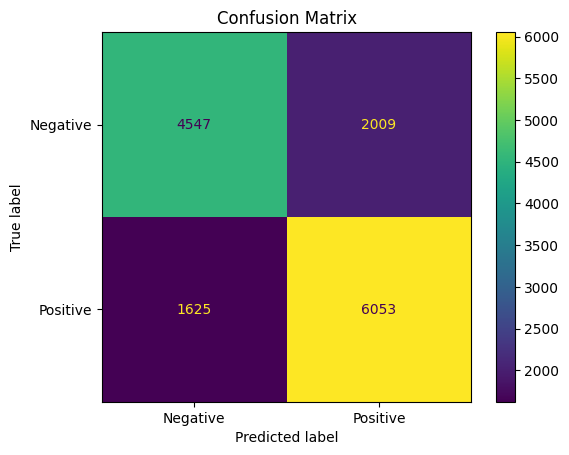

In [212]:

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

# Try to Increase Penalty of Missclassification of Minority Class

In [4]:
nominal_cols = ['KidneyDisease','HighBP','HighChol','CholCheck','Asthma','COPD','Smoker','Stroke','HeartDiseaseorAttack','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex',]
ordinal_cols = ['GenHlth','MentHlth','PhysHlth','AgeGroup','Education','Income']
bmi_col = ['BMI']

Col_Transformer = ColumnTransformer(
        remainder='passthrough',
        transformers=[
                ('ordinal_scaler', RobustScaler(), ordinal_cols),
                ('bmi_scaler', QuantileTransformer(), bmi_col),
                ('pass_nominal', 'passthrough', nominal_cols)]
                )

In [5]:
model_new = Pipeline([
    ("scaling",Col_Transformer),
    ("model", LogisticRegression(max_iter=30, penalty=None, solver="lbfgs", class_weight = "balanced"))
])

In [7]:
model_new.fit(X_train, y_train)

c:\Users\LENOVO\Desktop\470workplace\workplace_venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_scaler', ...), ('bmi_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
y_pred = model_new.predict(X_test)

In [9]:
accuracy_new = accuracy_score(y_test, y_pred)
accuracy_new


0.7242965472112091

In [10]:
precision_new = precision_score(y_test, y_pred)
precision_new


0.31260355683198937

In [11]:
recall_new = recall_score(y_test, y_pred)
recall_new


0.7507627006234249

In [12]:
f1_score_new = f1_score(y_test, y_pred)
f1_score_new


0.44141158120491325

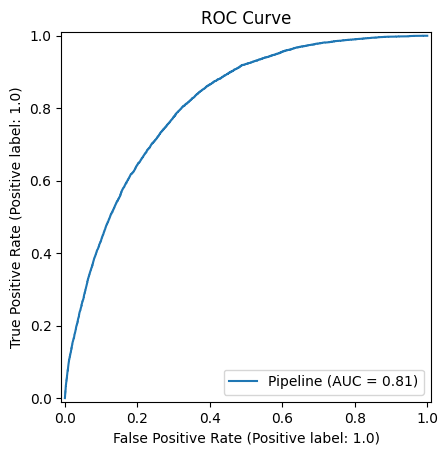

In [14]:
RocCurveDisplay.from_estimator(model_new, X_test, y_test)
plt.title("ROC Curve")
plt.show()


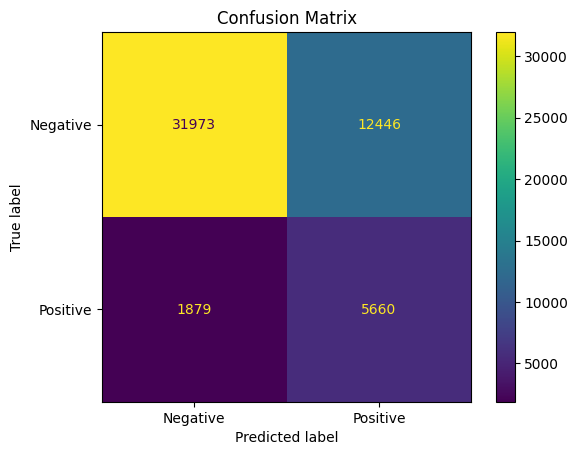

In [15]:

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()